In [1]:
import random
import pandas as pd
import numpy as np
import simpy as sp
from datetime import datetime, timedelta
import holidays
from scipy.stats import norm
random.seed(42)
np.random.seed(42)
# Create a holidays object for India in 2024
indian_holidays = holidays.India(years=[2023,2024,2025])

def is_public_holiday(date):
    return date.date() in indian_holidays

single_day_events = {
    "01/01/2023": ("New Year", "High"),
    "13/01/2023": ("Lohri", "Medium"),
    "23/01/2023": ("Netaji's Birthday", "Low"),
    "07/02/2023": ("Rose Day", "Medium"),
    "08/02/2023": ("Propose Day", "High"),
    "09/02/2023": ("Chocolate Day", "High"),
    "10/02/2023": ("Teddy Day", "Medium"),
    "11/02/2023": ("Hug Day", "Medium"),
    "12/02/2023": ("Kiss Day", "High"),
    "13/02/2023": ("Compliment Day", "Low"),
    "14/02/2023": ("Valentine's Day", "High"),
    "14/03/2023": ("Pi Day (Pizza Deals)", "High"),
    "20/03/2023": ("National Ravioli Day", "Medium"),
    "27/03/2023": ("National Seafood Bisque Day", "Medium"),
    "04/04/2023": ("National Pizza Day", "High"),
    "22/04/2023": ("Earth Day", "Low"),
    "30/04/2023": ("National Oatmeal Cookie Day", "Low"),
    "04/05/2023": ("Star Wars Day", "Medium"),
    "08/05/2023": ("Mother's Day", "High"),
    "12/05/2023": ("International Nurses Day", "Medium"),
    "15/05/2023": ("International Day of Families", "Low"),
    "31/05/2023": ("World No Tobacco Day", "Medium"),
    "01/06/2023": ("Global Parents' Day", "Medium"),
    "05/06/2023": ("World Environment Day", "High"),
    "18/06/2023": ("Father's Day", "High"),
    "21/06/2023": ("International Yoga Day", "Medium"),
    "30/06/2023": ("Social Media Day", "Medium"),
    "01/07/2023": ("Canada Day", "High"),
    "07/07/2023": ("World Chocolate Day", "Medium"),
    "11/07/2023": ("World Population Day", "Low"),
    "17/07/2023": ("World Emoji Day", "Low"),
    "20/07/2023": ("International Moon Day", "Medium"),
    "26/07/2023": ("National Coffee Milkshake Day", "Low"),
    "30/07/2023": ("International Day of Friendship", "Medium"),
    "08/08/2023": ("International Cat Day", "Medium"),
    "09/08/2023": ("National Book Lovers Day", "Low"),
    "12/08/2023": ("International Youth Day", "Medium"),
    "19/08/2023": ("World Photography Day", "Low"),
    "22/08/2023": ("World Plant Milk Day", "Low"),
    "26/08/2023": ("Women's Equality Day (USA)", "Medium"),
    "22/09/2023": ("World Car-Free Day", "Low"),
    "27/09/2023": ("World Tourism Day", "Low"),
    "01/10/2023": ("International Coffee Day", "High"),
    "04/10/2023": ("World Animal Day", "Medium"),
    "10/10/2023": ("World Mental Health Day", "High"),
    "14/10/2023": ("World Egg Day", "Medium"),
    "16/10/2023": ("World Food Day", "High"),
    "31/10/2023": ("Halloween", "High"),
    "01/11/2023": ("All Saints' Day", "Medium"),
    "13/11/2023": ("World Kindness Day", "Medium"),
    "14/11/2023": ("Children's Day (India)", "Low"),
    "20/11/2023": ("Universal Children's Day", "Medium"),
    "01/12/2023": ("World AIDS Day", "High"),
    "21/12/2023": ("Winter Solstice", "Medium"),
    "24/12/2023": ("Christmas Eve", "High"),
    "25/12/2023": ("Christmas Day", "High"),
    "31/12/2023": ("New Year's Eve", "High"),
    "01/01/2024": ("New Year's Day", "High"),
    "06/01/2024": ("National Technology Day", "Medium"),
    "15/01/2024": ("Makar Sankranti", "High"),
    "22/01/2024": ("National Hugging Day", "Medium"),
    "23/01/2024": ("Netaji Subhas Chandra Bose Jayanti", "Low"),
    "26/01/2024": ("Republic Day (India)", "High"),
    "30/01/2024": ("Martyrs' Day (India)", "Medium"),
    "07/02/2024": ("Rose Day", "High"),
    "08/02/2024": ("Propose Day", "Low"),
    "09/02/2024": ("Chocolate Day", "High"),
    "10/02/2024": ("Teddy Day", "Medium"),
    "11/02/2024": ("Hug Day", "High"),
    "12/02/2024": ("Kiss Day", "High"),
    "13/02/2024": ("Hug Day", "High"),
    "14/02/2024": ("Valentine's Day", "High"),
    "01/02/2024": ("National Freedom Day", "Medium"),
    "04/02/2024": ("World Cancer Day", "High"),
    "08/03/2024": ("International Women's Day", "High"),
    "14/03/2024": ("Pi Day", "Low"),
    "20/03/2024": ("International Day of Happiness", "Medium"),
    "22/03/2024": ("World Water Day", "High"),
    "27/03/2024": ("World Theatre Day", "Low"),
    "01/04/2024": ("April Fools' Day", "High"),
    "07/04/2024": ("World Health Day", "High"),
    "14/04/2024": ("Baisakhi", "Medium"),
    "22/04/2024": ("Earth Day", "High"),
    "23/04/2024": ("World Book Day", "Medium"),
    "01/05/2024": ("International Workers' Day", "High"),
    "04/05/2024": ("Star Wars Day", "Low"),
    "12/05/2024": ("Mother's Day", "High"),
    "25/05/2024": ("National Wine Day", "Low"),
    "31/05/2024": ("World No Tobacco Day", "High"),
    "01/06/2024": ("Global Day of Parents", "Medium"),
    "05/06/2024": ("World Environment Day", "High"),
    "17/06/2024": ("Father's Day", "High"),
    "21/06/2024": ("International Yoga Day", "High"),
    "04/07/2024": ("Independence Day (USA)", "High"),
    "07/07/2024": ("World Chocolate Day", "Low"),
    "11/07/2024": ("World Population Day", "Medium"),
    "17/07/2024": ("World Emoji Day", "Low"),
    "20/07/2024": ("International Chess Day", "Low"),
    "30/07/2024": ("International Day of Friendship", "High"),
    "12/08/2024": ("International Youth Day", "High"),
    "15/08/2024": ("Independence Day (India)", "High"),
    "19/08/2024": ("World Photography Day", "Low"),
    "29/08/2024": ("National Sports Day (India)", "High"),
    "05/09/2024": ("Teacher's Day (India)", "High"),
    "08/09/2024": ("International Literacy Day", "Medium"),
    "15/09/2024": ("International Day of Democracy", "Medium"),
    "27/09/2024": ("World Tourism Day", "Medium"),
    "29/09/2024": ("World Heart Day", "Medium"),
    "11/08/2024": ("Summer Olympics", "High"),
    "01/10/2024": ("International Day of Older Persons", "Medium"),
    "02/10/2024": ("Gandhi Jayanti (India)", "High"),
    "04/10/2024": ("World Animal Day", "Medium"),
    "05/10/2024": ("World Teachers' Day", "High"),
    "10/10/2024": ("World Mental Health Day", "High"),
    "16/10/2024": ("World Food Day", "High"),
    "24/10/2024": ("United Nations Day", "Medium"),
    "31/10/2024": ("Halloween", "High"),
    "20/11/2024": ("Universal Children's Day", "High"),
    "21/11/2024": ("World Television Day", "Low"),
    "10/12/2024": ("Human Rights Day", "High"),
    "12/12/2024": ("Gingerbread House Day", "Low"),
    "25/12/2024": ("Christmas Day", "High"),
    "31/12/2024": ("New Year's Eve", "High"),
}
    
multi_day_events = [
    (datetime(2023, 2, 10), datetime(2023, 2, 20), " FIFA Club World Cup", "High"),
    (datetime(2023, 3, 31), datetime(2023, 5, 28), "IPL", "High"),
    (datetime(2024, 3, 29), datetime(2024, 5, 26), "IPL", "High"),
    (datetime(2024, 2, 10), datetime(2024, 2, 20), "ICC Women's T20 World Cup", "High"),
]

# Function to determine the special event on a given date
def special_event(date):
    date_str = date.strftime("%d/%m/%Y")

    # Check for single-day events
    if date_str in single_day_events:
        return single_day_events[date_str]

    # Check for multi-day events
    for start_date, end_date, event_name, importance in multi_day_events:
        if start_date <= date <= end_date:
            return (event_name, importance)

    return ("None", "None")  # No event found
def competitive_promotion():
    return random.choice(["High", "Medium", "Low", "None"])

def economic_indicator(date):
    return random.uniform(0.8, 1.2)

# Time categories and their respective foods
time_categories = {
    "Morning": ["Beverage", "English Breakfast", "South Indian", "Pancakes & Waffles", "Smoothies & Juices", "Vegan Breakfast Bowls", "Parathas", "Cereal & Milk"],
    "Noon": ["Indian", "North Indian Thalis", "Chinese Combos", "Italian Pastas", "Biryani", "Seafood Platters", "Mediterranean", "Rajasthani Meals"],
    "Evening": ["Continental", "Appetizers", "Burgers & Sandwiches", "Pizza", "Momos & Dimsums", "Street Food", "Soups & Salads"],
    "Night": ["Chinese", "Indian Curries & Naans", "Grilled Meats", "Shawarma", "Kebabs"],
    "Midnight": ["Desserts", "Fast Food", "Bakery Items", "Maggi/Noodles", "Light Meals", "Wraps & Rolls"]
}

# Category prices and weights
category_prices = {
    "Beverage": 150, "English Breakfast": 300, "South Indian": 200, "Pancakes & Waffles": 400, 
    "Smoothies & Juices": 250, "Vegan Breakfast Bowls": 350, "Parathas": 180, "Cereal & Milk": 120,
    "Indian": 400, "North Indian Thalis": 500, "Chinese Combos": 450, "Italian Pastas": 600, 
    "Biryani": 350, "Seafood Platters": 800, "Mediterranean": 550, "Rajasthani Meals": 450, 
    "Continental": 700, "Appetizers": 300, "Burgers & Sandwiches": 250, "Pizza": 500, 
    "Momos & Dimsums": 200, "Street Food": 150, "Soups & Salads": 200, "Chinese": 400, 
    "Indian Curries & Naans": 350, "Grilled Meats": 700, "Shawarma": 250, "Kebabs": 400, 
    "Desserts": 300, "Fast Food": 250, "Bakery Items": 200, "Maggi/Noodles": 100, 
    "Light Meals": 200, "Wraps & Rolls": 150
}

category_weights = {
    "Beverage": 0.1, "English Breakfast": 0.2, "South Indian": 0.15, "Pancakes & Waffles": 0.1, 
    "Smoothies & Juices": 0.05, "Vegan Breakfast Bowls": 0.05, "Parathas": 0.15, "Cereal & Milk": 0.05,
    "Indian": 0.3, "North Indian Thalis": 0.1, "Chinese Combos": 0.2, "Italian Pastas": 0.15, 
    "Biryani": 0.25, "Seafood Platters": 0.1, "Mediterranean": 0.05, "Rajasthani Meals": 0.05, 
    "Continental": 0.2, "Appetizers": 0.1, "Burgers & Sandwiches": 0.2, "Pizza": 0.15, 
    "Momos & Dimsums": 0.1, "Street Food": 0.05, "Soups & Salads": 0.05, "Chinese": 0.1, 
    "Indian Curries & Naans": 0.2, "Grilled Meats": 0.15, "Shawarma": 0.05, "Kebabs": 0.1, 
    "Desserts": 0.05, "Fast Food": 0.2, "Bakery Items": 0.05, "Maggi/Noodles": 0.05, 
    "Light Meals": 0.1, "Wraps & Rolls": 0.15
}

# Function to simulate time of day trends
def time_of_day_trend(hour):
    return 0.5 + 0.5 * np.sin(2 * np.pi * (hour / 24 - 0.25))  # Peak at 6 PM

# Function to calculate special event boost (payday and festivals)
def special_event_boost(date):
    payday_boost = 1.5 if date.weekday() == 4 and (date.day - 1) // 7 % 2 == 0 else 1.0
    festival_boost = 1.8 if date == datetime(2024, 11, 12) else 1.0  # Example: Diwali
    festival_boost = 1.8 if date == datetime(2023, 11, 10) else 1.0
    return payday_boost * festival_boost

# Function to simulate weather effects
def weather_effect(date):
    weather = random.choice(["Rainy", "Clear", "Hot", "Cold"])
    if weather == "Rainy":
        return 1.5  # Higher demand during rain
    elif weather == "Hot":
        return 1.2  # Moderate boost for hot weather
    elif weather == "Cold":
        return 1.3  # Slight boost for cold weather
    else:
        return 1.0  # Normal demand

def weather_condition(date):
    return random.choice(["Rainy", "Clear", "Hot", "Cold"])

def competitive_promotion():
    return random.choice(["High", "Medium", "Low", "None"])

# Prepare a function for lead time simulation
def preparation_time():
    return np.random.lognormal(mean=2.65, sigma=0.05)

def delivery_time(distance):
    # Delivery time logic based on distance
    if distance < 5:
        return np.random.uniform(15, 20)
    elif 5 <= distance < 10:
        return np.random.uniform(30, 35)
    else:
        return np.random.uniform(40, 45)

# Time categories and their respective food lists
#time_categories = ["Morning", "Noon", "Evening", "Night", "Midnight"]
segments = ["Budget Conscious", "Time Sensitive", "Loyalist"]

# Simulating customer segmentation impact
def segment_effect(segment, zomato_price, swiggy_price, zomato_lead_time, swiggy_lead_time):
    if segment == "Budget Conscious":
        return (1 - 0.2 * (zomato_price > swiggy_price), 1 - 0.2 * (swiggy_price > zomato_price))
    elif segment == "Time Sensitive":
        return (1 - 0.1 * (zomato_lead_time > swiggy_lead_time), 1 - 0.1 * (swiggy_lead_time > zomato_lead_time))
    elif segment == "Loyalist":
        return (1.1, 1.1)
    return (1, 1)
# Data collection
data = []

# Create a SimPy environment
env = sp.Environment()
# Define time-dependent arrival rates with day-specific variations
def get_arrival_rate(day, time_category):
    if day in ["Saturday", "Sunday"]:
        rates = {
            "Morning": 3,
            "Noon": 8,
            "Evening": 10,
            "Night": 6,
            "Midnight": 5
        }
    elif day == "Friday":
        rates = {
            "Morning": 2,
            "Noon": 6,
            "Evening": 8,
            "Night": 6,  # Higher on Friday night
            "Midnight": 4  # Higher on Friday midnight
        }
    else:
        rates = {
            "Morning": 2,
            "Noon": 6,
            "Evening": 8,
            "Night": 4,
            "Midnight": 2.5
        }
    return rates[time_category]
def seasonality_factor(date):
    month = date.month
    weekday = date.weekday()
    weekend_boost = 1.2 if weekday in [5, 6] else 1.0
    festive_boost = 1.3 if month in [12, 1] else 1.0
    summer_slowdown = 0.8 if month in [5, 6] else 1.0
    return weekend_boost * festive_boost * summer_slowdown

time_multipliers = {
    "Morning": 0.8,
    "Noon": 1.2,
    "Evening": 1.5,
    "Night": 1.1,
    "Midnight": 0.7
}

def weather_impact(date):
    # Rainy season in July-August
    month = date.month
    rain_boost = 1.2 if month in [7, 8] else 1.0
    return rain_boost
    
# Modify arrival_time to take day and time_category as input
def arrival_time(day, time_category):
    rate = get_arrival_rate(day, time_category)
    return np.random.exponential(1 / rate)

# Updated process to include day names explicitly
def lead_time_process():
    global data

    day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    start_date = datetime(2023, 1, 1)
    
    for week in range(1, 106):  # Simulate for 52 weeks (1 year)
        for day_index, day in enumerate(day_names):  # Loop through each day by name
            current_date = start_date + timedelta(days=(week - 1) * 7 + day_index)
            for time_category in ["Morning", "Noon", "Evening", "Night", "Midnight"]:
                time_factor = time_multipliers[time_category]
                hour = {"Morning": 8, "Noon": 12, "Evening": 18, "Night": 21, "Midnight": 23}[time_category]
                daily_trend = time_of_day_trend(hour)
                holiday = bool(is_public_holiday(current_date))
                event, event_importance = special_event(current_date)
                weather = weather_condition(current_date)
                economic_index = economic_indicator(current_date)
                # Randomly select food for Zomato and Swiggy
                zomato_food = random.choice(time_categories[time_category])
                swiggy_food = random.choice(time_categories[time_category])
                
                # Price and sensitivity
                p1 = category_prices[zomato_food]
                p2 = category_prices[swiggy_food]
                if is_public_holiday(current_date):
                    discount_factor = random.uniform(0.85, 0.90)  # 10-15% off
                    p1 *= discount_factor
                    p2 *= discount_factor
                elif event_importance == "High":
                    discount_factor = random.uniform(0.80, 0.85)  # 15-20% discount
                    p1 *= discount_factor
                    p2 *= discount_factor
                elif event_importance == "Medium":
                    discount_factor = random.uniform(0.85, 0.90)  # 10-15% discount
                    p1 *= discount_factor
                    p2 *= discount_factor
                elif event_importance == "Low":
                    discount_factor = random.uniform(0.95, 1.00)  # 0-5% discount (Almost no change)
                    p1 *= discount_factor
                    p2 *= discount_factor

                
                zomato_food_sensitivity = category_weights[zomato_food]
                swiggy_food_sensitivity = category_weights[swiggy_food]
                
                # Zomato price calculation
                distance_zomato = random.uniform(1, 15)
                price_with_gst_zomato = p1 * 1.05
                platform_fee_zomato = 10
                delivery_fee_zomato = 32 + (2 * distance_zomato)
                small_order_fee = 15 if p1 < 150 else 0
                zomato_price = round(price_with_gst_zomato + platform_fee_zomato + delivery_fee_zomato + small_order_fee)
                
                # Swiggy price calculation
                distance_swiggy = random.uniform(1, 15)
                price_with_gst_swiggy = p2 * 1.05
                gst_on_platform_fee_swiggy = 1.80
                platform_fee_swiggy = 10
                delivery_fee_swiggy = 28
                swiggy_price = round(price_with_gst_swiggy + gst_on_platform_fee_swiggy + platform_fee_swiggy + delivery_fee_swiggy)
                
                
                # Use dynamic arrival rates based on day and time category
                arrival_time_zomato = env.now + arrival_time(day, time_category)
                arrival_time_swiggy = env.now + arrival_time(day, time_category)
                
                prep_time_zomato = preparation_time()
                del_time_zomato = delivery_time(distance_zomato)
                service_time_zomato = prep_time_zomato + del_time_zomato
                finish_time_zomato = arrival_time_zomato + service_time_zomato
                zomato_lead_time = finish_time_zomato - arrival_time_zomato
                
                prep_time_swiggy = preparation_time()
                del_time_swiggy = delivery_time(distance_swiggy)
                service_time_swiggy = prep_time_swiggy + del_time_swiggy
                finish_time_swiggy = arrival_time_swiggy + service_time_swiggy
                swiggy_lead_time = finish_time_swiggy - arrival_time_swiggy

                # Segment and competition effects
                segment = random.choice(segments)
                seg_zomato, seg_swiggy = segment_effect(segment, p1, p2, zomato_lead_time, swiggy_lead_time)
                

                # Updated demand calculations
                zomato_demand = (
                    10000 - 
                    (zomato_food_sensitivity * zomato_price) -  # Increase impact of price sensitivity
                    (0.15 * zomato_lead_time) +  # Increase impact of lead time on demand
                    np.random.normal(0, 20) +  # Larger random fluctuation for more noise
                    0.1 * (swiggy_price - zomato_price) -  # Price difference effect
                    0.05 * (zomato_lead_time - swiggy_lead_time)  # Lead time comparison effect
                )
                zomato_demand *= seasonality_factor(current_date) * time_factor * weather_impact(current_date) * daily_trend * special_event_boost(current_date) * weather_effect(current_date) * seg_swiggy

                swiggy_demand = (
                    12000 - 
                    (swiggy_food_sensitivity * swiggy_price) -  # Increase impact of price sensitivity
                    (0.15 * swiggy_lead_time) +  # Increase impact of lead time on demand
                    np.random.normal(0, 20) +  # Larger random fluctuation for more noise
                    0.1 * (zomato_price - swiggy_price) -  # Price difference effect
                    0.05 * (swiggy_lead_time - zomato_lead_time)  # Lead time comparison effect
                )
                swiggy_demand *= seasonality_factor(current_date) * daily_trend * special_event_boost(current_date) * weather_effect(current_date) * seg_zomato * time_factor * weather_impact(current_date)

                # Random spikes for unpredictability
                #zomato_demand += np.random.normal(0, 50) + random.choice([0, 0, 200])
                #swiggy_demand += np.random.normal(0, 50) + random.choice([0, 0, 200])

                # Add to data
                data.append([week, current_date.strftime("%d/%m/%Y"), day, time_category, zomato_food, zomato_price, zomato_demand, 
                             swiggy_food, swiggy_price, swiggy_demand, zomato_lead_time, swiggy_lead_time, 
                             distance_zomato, distance_swiggy, holiday, event,event_importance, weather, economic_index])

                # Yield control
                yield env.timeout(0.1)

# Running the simulation
env.process(lead_time_process())
env.run()

# Create the DataFrame with proper column names
df = pd.DataFrame(data, columns=["Week", "Date", "Day", "Time", "Zomato Food", "Zomato Price", "Zomato Demand", 
                                 "Swiggy Food", "Swiggy Price", "Swiggy Demand", "Zomato Lead Time", 
                                 "Swiggy Lead Time", "Zomato Distance", "Swiggy Distance", "holiday", "event", "Event Importance","weather","economic_index"])

# Display the resulting data
df


,Week,Date,Day,Time,Zomato Food,Zomato Price,Zomato Demand,Swiggy Food,Swiggy Price,Swiggy Demand,Zomato Lead Time,Swiggy Lead Time,Zomato Distance,Swiggy Distance,holiday,event,Event Importance,weather,economic_index
0,1,01/01/2023,Monday,Morning,Smoothies & Juices,278,15474.280979,Pancakes & Waffles,380,16006.491353,55.400005,56.053964,11.310597,10.473793,False,New Year,High,Rainy,0.810004
1,1,01/01/2023,Monday,Noon,Italian Pastas,565,26542.500909,Italian Pastas,560,24450.176995,29.734785,30.460288,1.371504,3.783727,False,New Year,High,Rainy,0.811919
2,1,01/01/2023,Monday,Evening,Soups & Salads,235,12644.453876,Soups & Salads,208,14015.767271,54.915826,56.209998,12.281470,10.773952,False,New Year,High,Cold,1.035706
3,1,01/01/2023,Monday,Night,Grilled Meats,638,3271.639486,Chinese,378,4964.566607,31.811698,55.085377,2.354029,12.864921,False,New Year,High,Clear,1.182885
4,1,01/01/2023,Monday,Midnight,Maggi/Noodles,169,186.280078,Desserts,300,299.901103,54.316432,47.971546,12.611665,9.659277,False,New Year,High,Cold,1.014491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3670,105,04/01/2025,Sunday,Morning,English Breakfast,383,15328.876482,Smoothies & Juices,302,16081.966356,56.238949,32.390318,12.820437,1.048834,False,None,None,Rainy,1.035054
3671,105,04/01/2025,Sunday,Noon,Italian Pastas,688,27783.079383,Chinese Combos,512,21396.036921,46.352453,45.426320,7.994318,6.687029,False,None,None,Rainy,0.819596
3672,105,04/01/2025,Sunday,Evening,Pizza,583,15027.827390,Soups & Salads,250,12666.899163,47.174262,32.862497,7.940695,1.696535,False,None,None,Cold,0.985976
3673,105,04/01/2025,Sunday,Night,Chinese,480,3566.768625,Chinese,460,3967.113501,47.719217,48.547201,8.884354,6.975234,False,None,None,Cold,1.002608


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# Aggregate daily demand for each food category (sum Zomato & Swiggy demand)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)  # Ensure Date is in datetime format
df['Total Demand'] = df['Zomato Demand'] + df['Swiggy Demand']

daily_demand = df.groupby(['Date', 'Zomato Food', 'Swiggy Food'])[['Total Demand']].sum().reset_index()

def calculate_newsvendor_stock(daily_demand, cu_rest=0.1, co_rest=0.3, cu_supp=0.2, co_supp=0.4):
    """
    Calculate optimal inventory levels for restaurants and suppliers using the Newsvendor model.
    :param daily_demand: DataFrame with daily demand per food category
    :param cu_rest: Cost per unit of underage for restaurant
    :param co_rest: Cost per unit of overage for restaurant
    :param cu_supp: Cost per unit of underage for supplier
    :param co_supp: Cost per unit of overage for supplier
    :return: DataFrame with optimal inventory levels
    """
    # Compute mean and standard deviation of demand per food category
    summary = daily_demand.groupby(['Zomato Food', 'Swiggy Food'])['Total Demand'].agg(['mean', 'std']).reset_index()
    
    # Set a higher z-score for restaurants to ensure safety stock
    z_value_rest = 0.68  # ~90% service level (higher than default)
    
    # Compute optimal restaurant inventory (targeting ~45,000 when mean demand is ~40,000)
    summary['Restaurant Inventory'] = (summary['mean'] + z_value_rest * summary['std']).round()

    return summary

# Apply the model
optimal_stock = calculate_newsvendor_stock(daily_demand)

# Merge optimal inventory into the original DataFrame
df = df.merge(optimal_stock[['Zomato Food', 'Swiggy Food', 'Restaurant Inventory']], 
              on=['Zomato Food', 'Swiggy Food'], how='left')

# Remove duplicate inventory columns if they exist
df = df.loc[:, ~df.columns.duplicated()].copy()

df


,Week,Date,Day,Time,Zomato Food,Zomato Price,Zomato Demand,Swiggy Food,Swiggy Price,Swiggy Demand,...,Swiggy Lead Time,Zomato Distance,Swiggy Distance,holiday,event,Event Importance,weather,economic_index,Total Demand,Restaurant Inventory
0,1,2023-01-01,Monday,Morning,Smoothies & Juices,278,15474.280979,Pancakes & Waffles,380,16006.491353,...,56.053964,11.310597,10.473793,False,New Year,High,Rainy,0.810004,31480.772332,22096.0
1,1,2023-01-01,Monday,Noon,Italian Pastas,565,26542.500909,Italian Pastas,560,24450.176995,...,30.460288,1.371504,3.783727,False,New Year,High,Rainy,0.811919,50992.677904,43975.0
2,1,2023-01-01,Monday,Evening,Soups & Salads,235,12644.453876,Soups & Salads,208,14015.767271,...,56.209998,12.281470,10.773952,False,New Year,High,Cold,1.035706,26660.221147,28770.0
3,1,2023-01-01,Monday,Night,Grilled Meats,638,3271.639486,Chinese,378,4964.566607,...,55.085377,2.354029,12.864921,False,New Year,High,Clear,1.182885,8236.206093,5824.0
4,1,2023-01-01,Monday,Midnight,Maggi/Noodles,169,186.280078,Desserts,300,299.901103,...,47.971546,12.611665,9.659277,False,New Year,High,Cold,1.014491,486.181181,464.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3670,105,2025-01-04,Sunday,Morning,English Breakfast,383,15328.876482,Smoothies & Juices,302,16081.966356,...,32.390318,12.820437,1.048834,False,None,None,Rainy,1.035054,31410.842838,21792.0
3671,105,2025-01-04,Sunday,Noon,Italian Pastas,688,27783.079383,Chinese Combos,512,21396.036921,...,45.426320,7.994318,6.687029,False,None,None,Rainy,0.819596,49179.116304,44368.0
3672,105,2025-01-04,Sunday,Evening,Pizza,583,15027.827390,Soups & Salads,250,12666.899163,...,32.862497,7.940695,1.696535,False,None,None,Cold,0.985976,27694.726553,25845.0
3673,105,2025-01-04,Sunday,Night,Chinese,480,3566.768625,Chinese,460,3967.113501,...,48.547201,8.884354,6.975234,False,None,None,Cold,1.002608,7533.882126,6162.0


In [3]:

# Calculate updated variances
var_supplier_order = np.var(df['Restaurant Inventory'])
var_demand_zomato = np.var(df['Zomato Demand'])
var_demand_swiggy = np.var(df['Swiggy Demand'])

# Recalculate Bullwhip Effects
bullwhip_zomato = var_supplier_order / var_demand_zomato
bullwhip_swiggy = var_supplier_order / var_demand_swiggy
final_bullwhip_effect = (bullwhip_zomato + bullwhip_swiggy) / 2

# Print results
print("Updated Bullwhip Effect for Zomato:", bullwhip_zomato)
print("Updated Bullwhip Effect for Swiggy:", bullwhip_swiggy)
print("Updated Final Bullwhip Effect (Average):", final_bullwhip_effect)

Updated Bullwhip Effect for Zomato: 5.590726558077649
Updated Bullwhip Effect for Swiggy: 3.8307455627834
Updated Final Bullwhip Effect (Average): 4.710736060430524


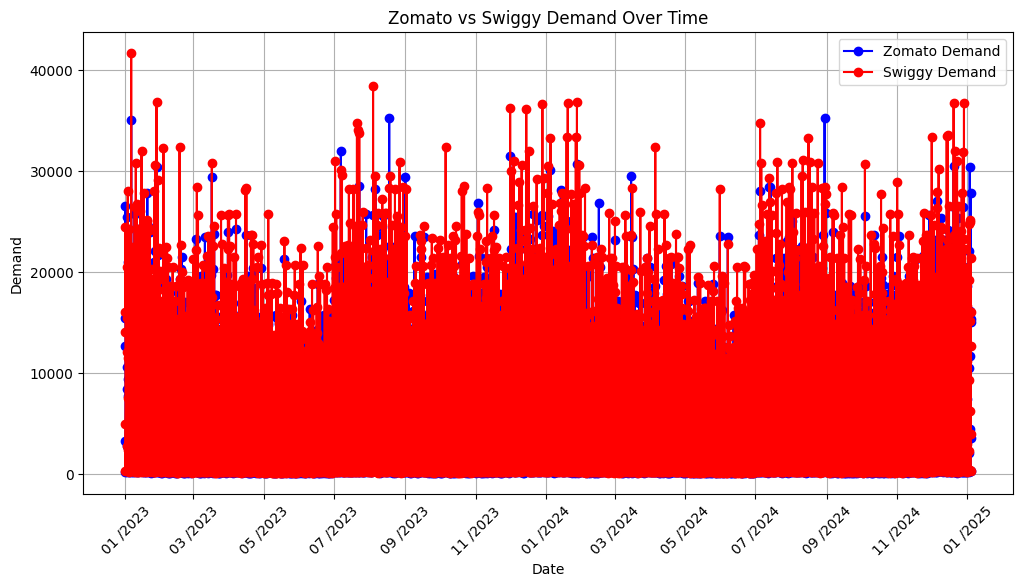

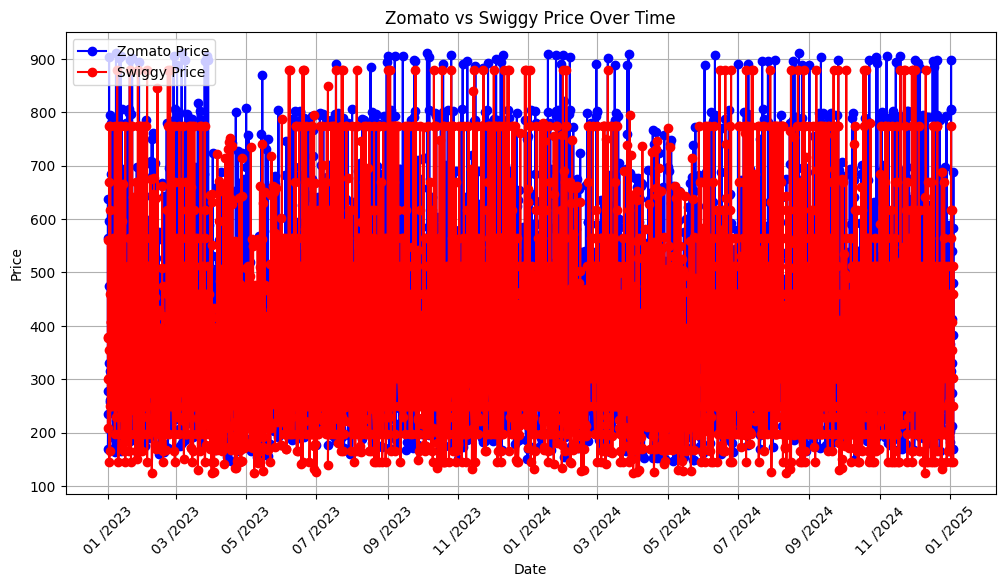

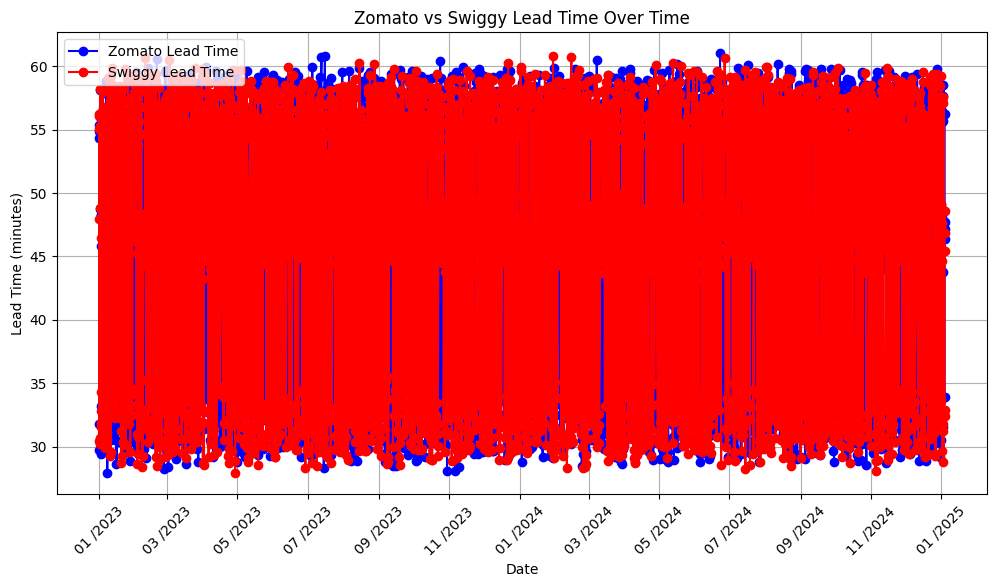

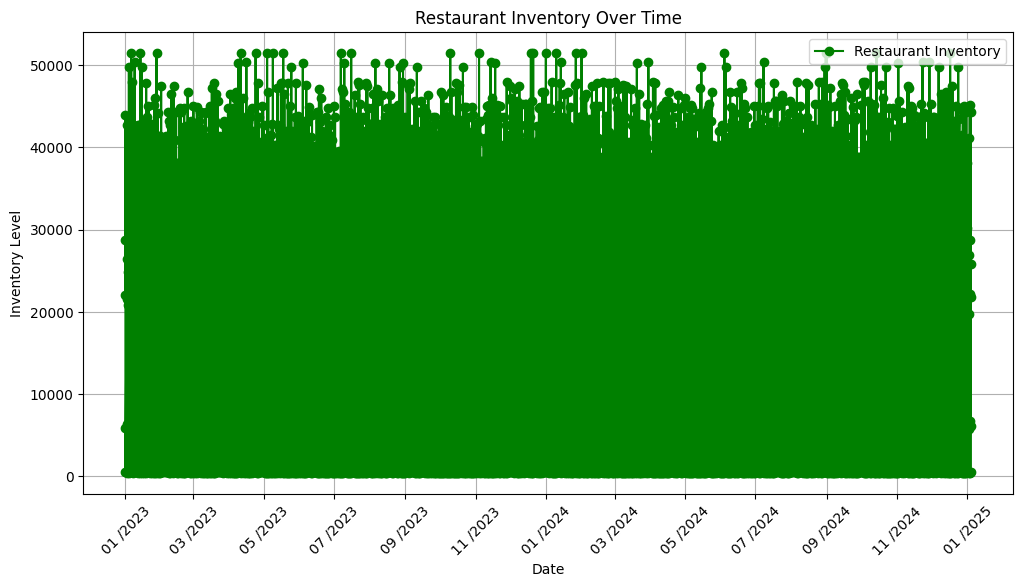

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert Date column to datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Function to plot graphs
def plot_graph(y_values, y_label, title, colors, labels):
    plt.figure(figsize=(12, 6))
    for i, y in enumerate(y_values):
        plt.plot(df['Date'], y, label=labels[i], color=colors[i], marker='o', linestyle='-')
    plt.xlabel('Date')
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Show every 2 months
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m /%Y'))  
    plt.grid(True)
    plt.show()

# Plot graphs
plot_graph([df['Zomato Demand'], df['Swiggy Demand']], 'Demand', 'Zomato vs Swiggy Demand Over Time', ['blue', 'red'], ['Zomato Demand', 'Swiggy Demand'])
plot_graph([df['Zomato Price'], df['Swiggy Price']], 'Price', 'Zomato vs Swiggy Price Over Time', ['blue', 'red'], ['Zomato Price', 'Swiggy Price'])
plot_graph([df['Zomato Lead Time'], df['Swiggy Lead Time']], 'Lead Time (minutes)', 'Zomato vs Swiggy Lead Time Over Time', ['blue', 'red'], ['Zomato Lead Time', 'Swiggy Lead Time'])
plot_graph(
    [df['Restaurant Inventory']], 
    'Inventory Level', 
    'Restaurant Inventory Over Time', 
    ['green'], 
    ['Restaurant Inventory']
)


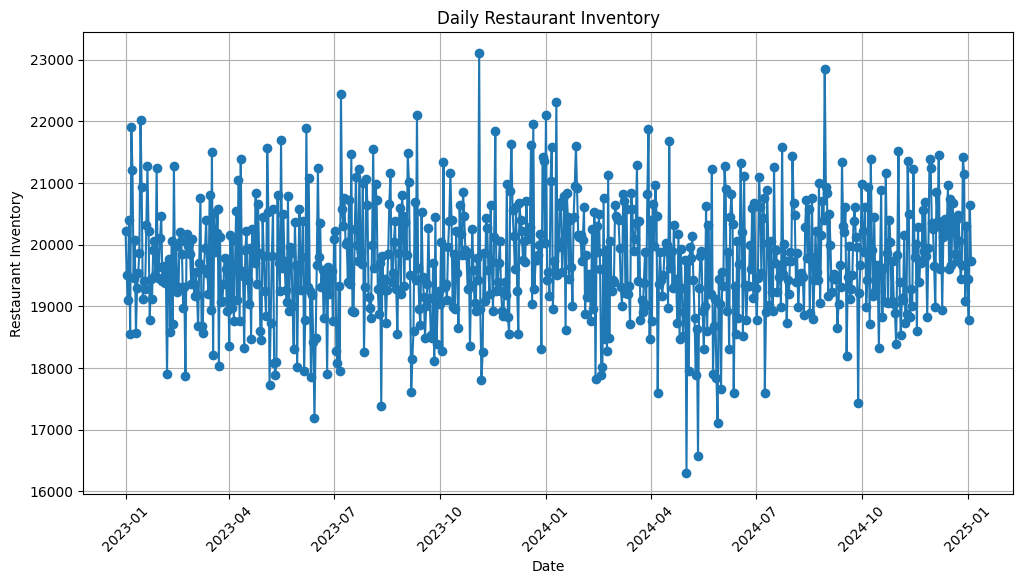

In [5]:
# Calculate daily mean optimal inventory
daily_optimal_inventory = df.groupby('Date')['Restaurant Inventory'].mean().reset_index()

# Plot the optimal inventory trend
plt.figure(figsize=(12, 6))
plt.plot(daily_optimal_inventory['Date'], daily_optimal_inventory['Restaurant Inventory'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Restaurant Inventory')
plt.title('Daily Restaurant Inventory')
plt.xticks(rotation=45)
plt.grid()
plt.show()


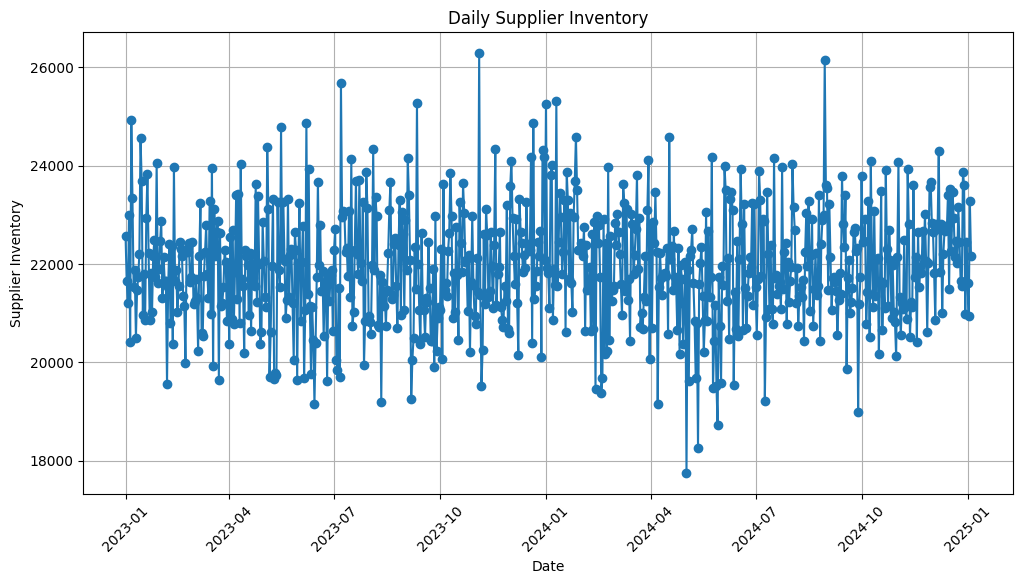

In [6]:
# Calculate daily mean optimal inventory
daily_optimal_inventory = df.groupby('Date')['Supplier Inventory'].mean().reset_index()

# Plot the optimal inventory trend
plt.figure(figsize=(12, 6))
plt.plot(daily_optimal_inventory['Date'], daily_optimal_inventory['Supplier Inventory'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Supplier Inventory')
plt.title('Daily Supplier Inventory')
plt.xticks(rotation=45)
plt.grid()
plt.show()


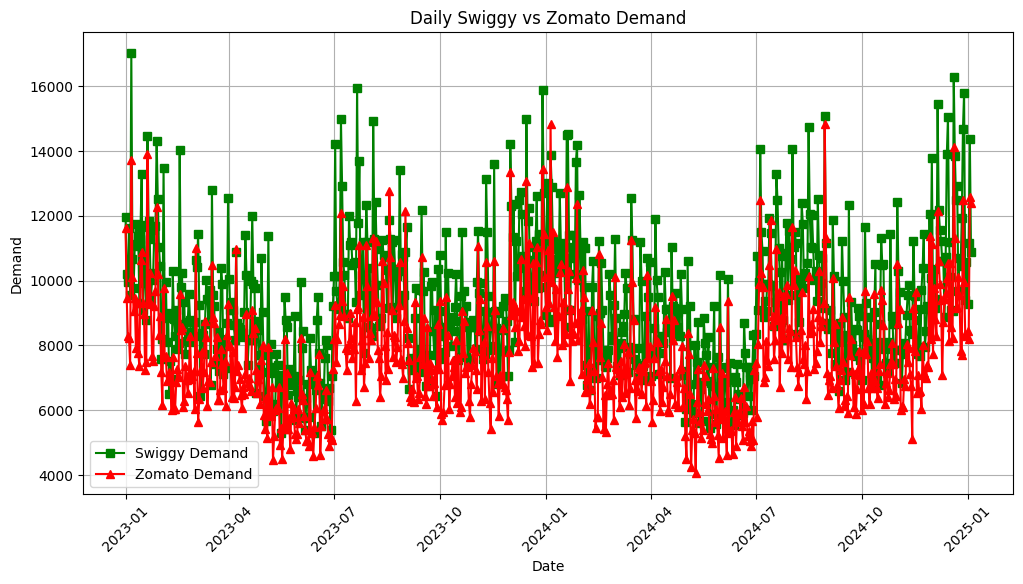

In [7]:
# Calculate daily mean values
daily_swiggy_demand = df.groupby('Date')['Swiggy Demand'].mean().reset_index()
daily_zomato_demand = df.groupby('Date')['Zomato Demand'].mean().reset_index()

# Create the figure
plt.figure(figsize=(12, 6))

# Plot Swiggy Demand
plt.plot(daily_swiggy_demand['Date'], daily_swiggy_demand['Swiggy Demand'], marker='s', linestyle='-', color='green', label='Swiggy Demand')

# Plot Zomato Demand
plt.plot(daily_zomato_demand['Date'], daily_zomato_demand['Zomato Demand'], marker='^', linestyle='-', color='red', label='Zomato Demand')

# Labels and Title
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('Daily Swiggy vs Zomato Demand')

# Grid, Legend, and Formatting
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show Plot
plt.show()



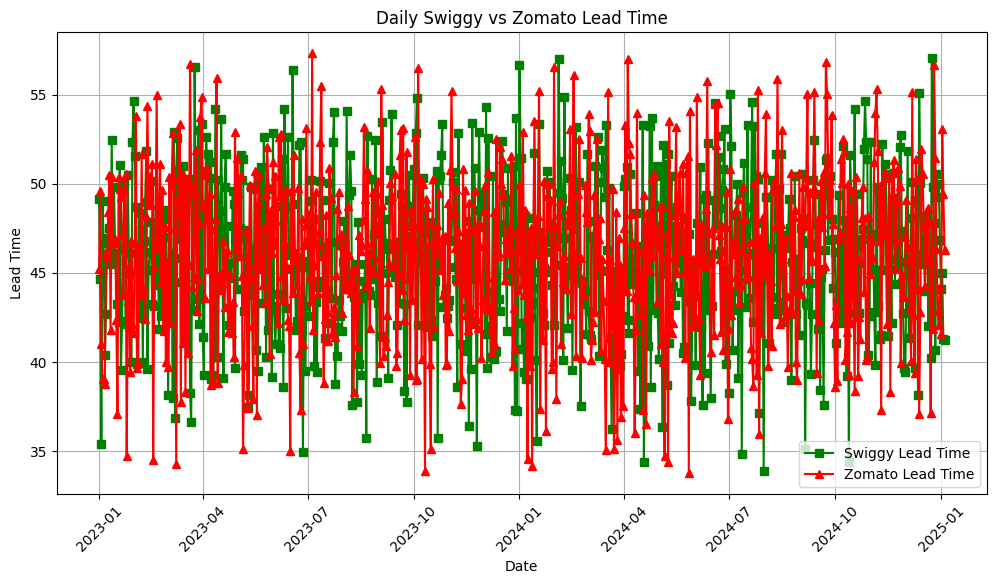

In [8]:
# Calculate daily mean values
daily_swiggy_demand = df.groupby('Date')['Swiggy Lead Time'].mean().reset_index()
daily_zomato_demand = df.groupby('Date')['Zomato Lead Time'].mean().reset_index()

# Create the figure
plt.figure(figsize=(12, 6))

# Plot Swiggy Demand
plt.plot(daily_swiggy_demand['Date'], daily_swiggy_demand['Swiggy Lead Time'], marker='s', linestyle='-', color='green', label='Swiggy Lead Time')

# Plot Zomato Demand
plt.plot(daily_zomato_demand['Date'], daily_zomato_demand['Zomato Lead Time'], marker='^', linestyle='-', color='red', label='Zomato Lead Time')

# Labels and Title
plt.xlabel('Date')
plt.ylabel('Lead Time')
plt.title('Daily Swiggy vs Zomato Lead Time')

# Grid, Legend, and Formatting
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show Plot
plt.show()



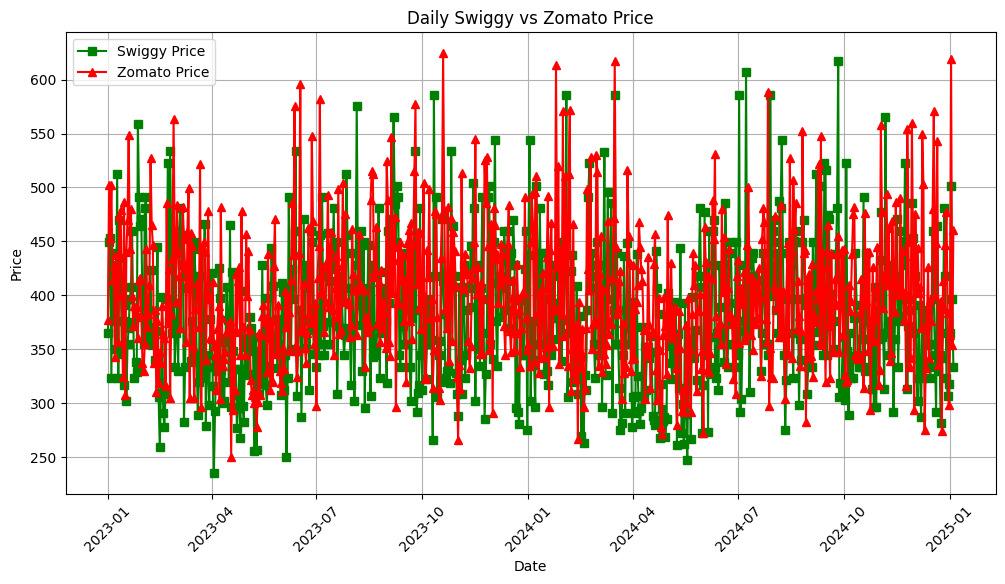

In [9]:
# Calculate daily mean values
daily_swiggy_demand = df.groupby('Date')['Swiggy Price'].mean().reset_index()
daily_zomato_demand = df.groupby('Date')['Zomato Price'].mean().reset_index()

# Create the figure
plt.figure(figsize=(12, 6))

# Plot Swiggy Demand
plt.plot(daily_swiggy_demand['Date'], daily_swiggy_demand['Swiggy Price'], marker='s', linestyle='-', color='green', label='Swiggy Price')

# Plot Zomato Demand
plt.plot(daily_zomato_demand['Date'], daily_zomato_demand['Zomato Price'], marker='^', linestyle='-', color='red', label='Zomato Price')

# Labels and Title
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Daily Swiggy vs Zomato Price')

# Grid, Legend, and Formatting
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show Plot
plt.show()



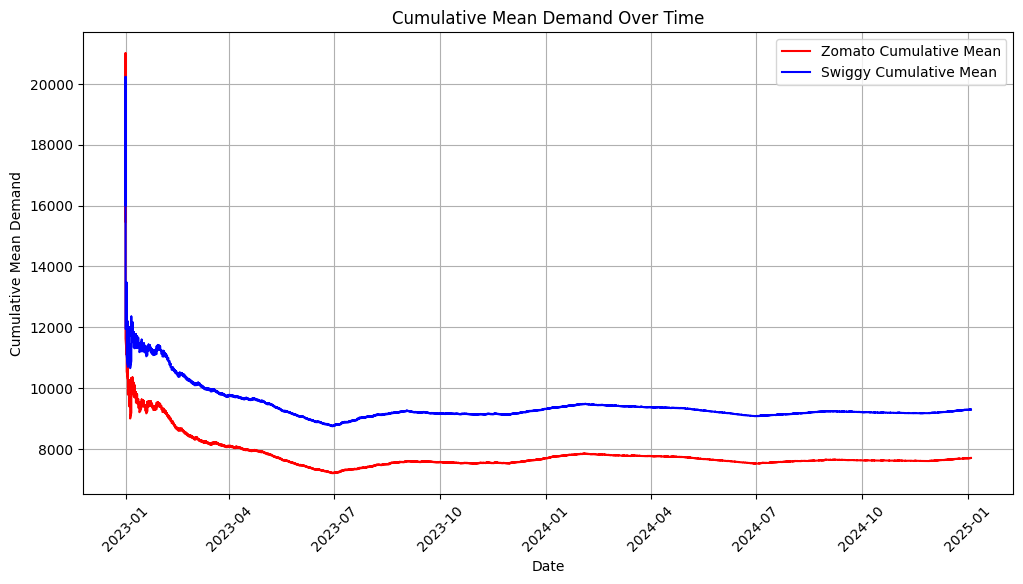

In [13]:
import matplotlib.pyplot as plt
# Compute cumulative mean
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
# Sort data by date
df["Zomato Cumulative Mean"] = df["Zomato Demand"].expanding().mean()
df["Swiggy Cumulative Mean"] = df["Swiggy Demand"].expanding().mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Zomato Cumulative Mean"], label="Zomato Cumulative Mean", color='red')
plt.plot(df["Date"], df["Swiggy Cumulative Mean"], label="Swiggy Cumulative Mean", color='blue')

# Formatting the plot
plt.xlabel("Date")
plt.ylabel("Cumulative Mean Demand")
plt.title("Cumulative Mean Demand Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show the plot
plt.show()

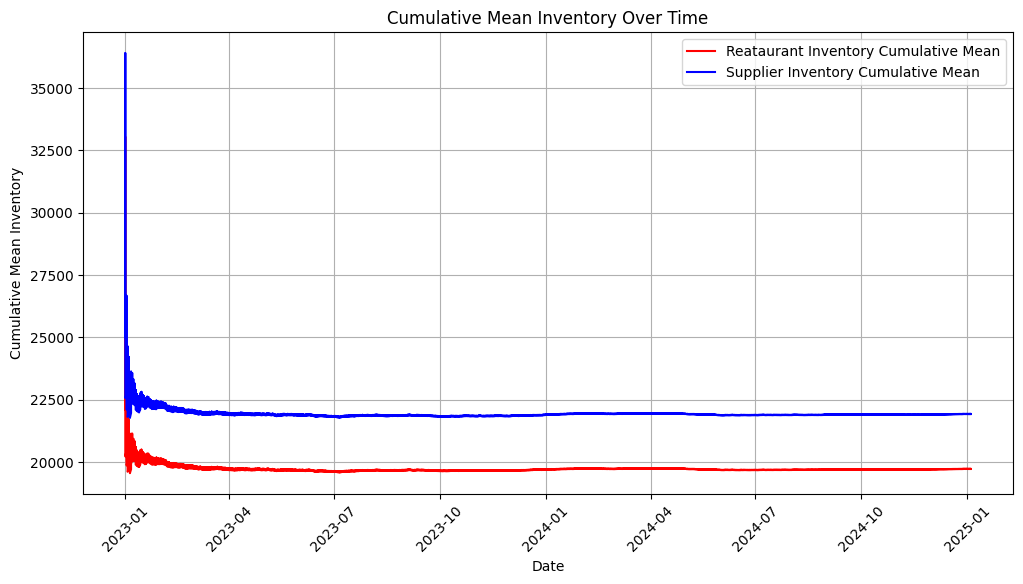

In [14]:
import matplotlib.pyplot as plt
# Compute cumulative mean
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
# Sort data by date
df["Restaurant Cumulative Mean"] = df["Restaurant Inventory"].expanding().mean()
df["Supplier Cumulative Mean"] = df["Supplier Inventory"].expanding().mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Restaurant Cumulative Mean"], label="Reataurant Inventory Cumulative Mean", color='red')
plt.plot(df["Date"], df["Supplier Cumulative Mean"], label="Supplier Inventory Cumulative Mean", color='blue')

# Formatting the plot
plt.xlabel("Date")
plt.ylabel("Cumulative Mean Inventory")
plt.title("Cumulative Mean Inventory Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show the plot
plt.show()

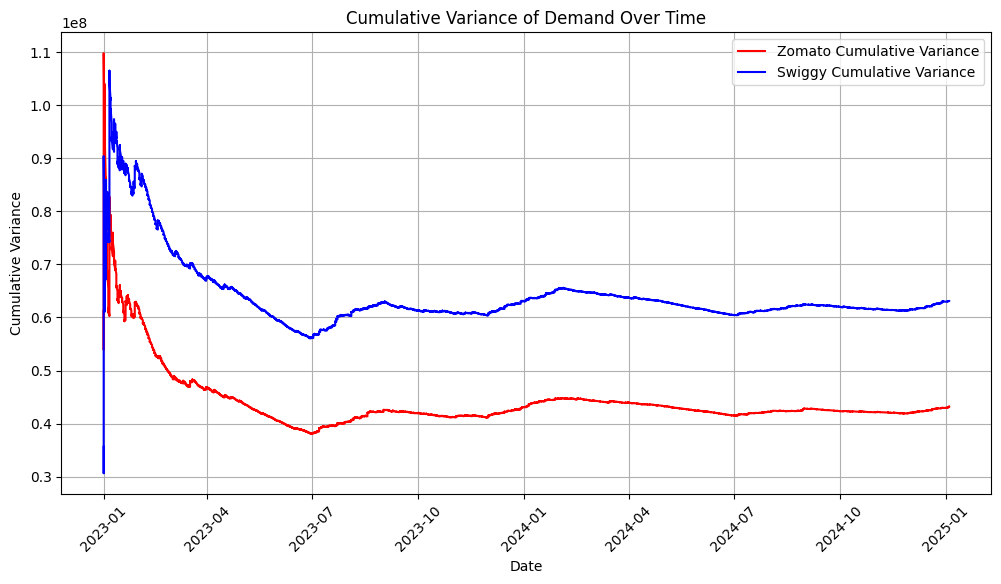

In [15]:
# Compute cumulative variance
df["Zomato Cumulative Variance"] = df["Zomato Demand"].expanding().var()
df["Swiggy Cumulative Variance"] = df["Swiggy Demand"].expanding().var()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Zomato Cumulative Variance"], label="Zomato Cumulative Variance", color='red')
plt.plot(df["Date"], df["Swiggy Cumulative Variance"], label="Swiggy Cumulative Variance", color='blue')

# Formatting the plot
plt.xlabel("Date")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance of Demand Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show the plot
plt.show()

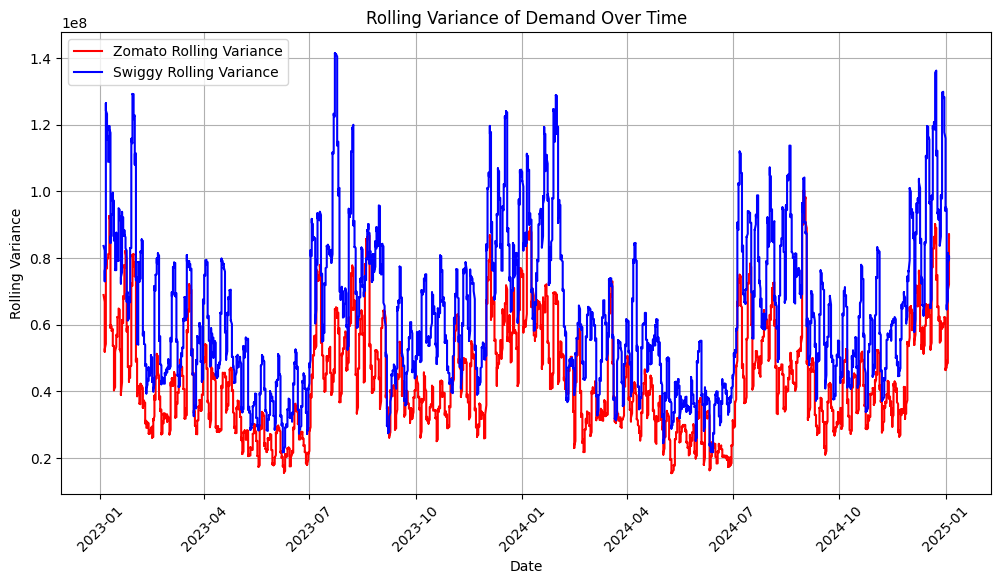

In [16]:
# Define rolling window size (e.g., 30 days)
window_size = 20

# Compute rolling variance
df["Zomato Rolling Variance"] = df["Zomato Demand"].rolling(window=window_size).var()
df["Swiggy Rolling Variance"] = df["Swiggy Demand"].rolling(window=window_size).var()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Zomato Rolling Variance"], label="Zomato Rolling Variance", color='red')
plt.plot(df["Date"], df["Swiggy Rolling Variance"], label="Swiggy Rolling Variance", color='blue')

# Formatting the plot
plt.xlabel("Date")
plt.ylabel("Rolling Variance")
plt.title("Rolling Variance of Demand Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show the plot
plt.show()

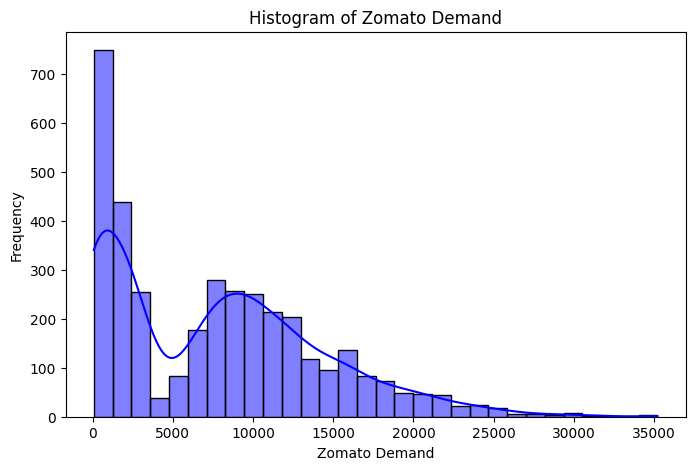

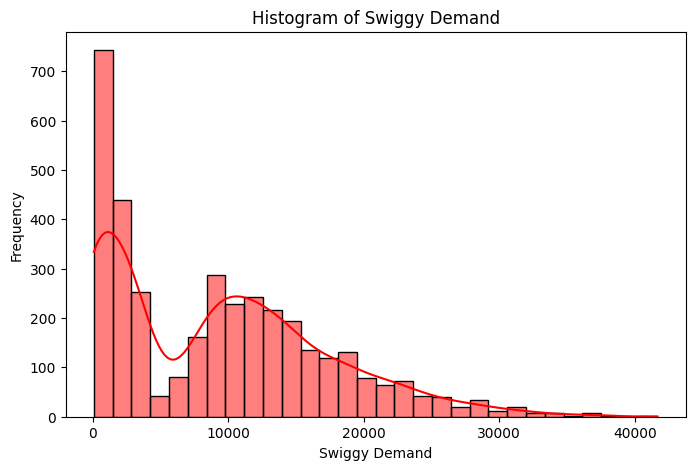

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
df['Date'] = pd.to_datetime(df['Date'], format="%d/%m/%Y")  # Convert date column to datetime
df = df.sort_values('Date')  # Ensure data is sorted by date
# Histogram for Zomato demand
plt.figure(figsize=(8, 5))
sns.histplot(df['Zomato Demand'], bins=30, kde=True, color='blue')
plt.title('Histogram of Zomato Demand')
plt.xlabel('Zomato Demand')
plt.ylabel('Frequency')
plt.show()

# Histogram for Swiggy demand
plt.figure(figsize=(8, 5))
sns.histplot(df['Swiggy Demand'], bins=30, kde=True, color='red')
plt.title('Histogram of Swiggy Demand')
plt.xlabel('Swiggy Demand')
plt.ylabel('Frequency')
plt.show()

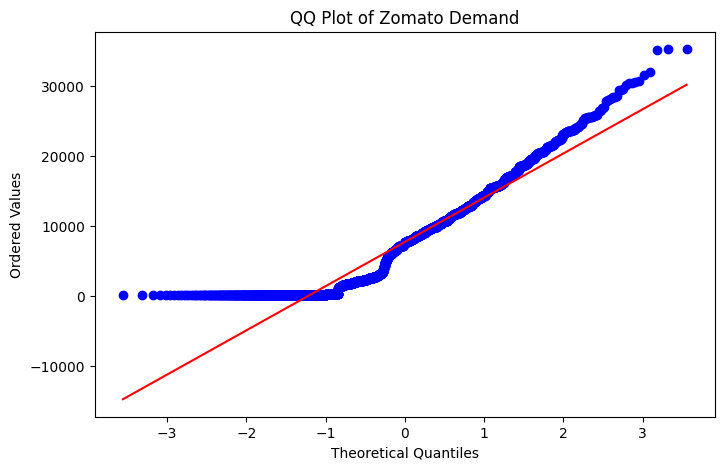

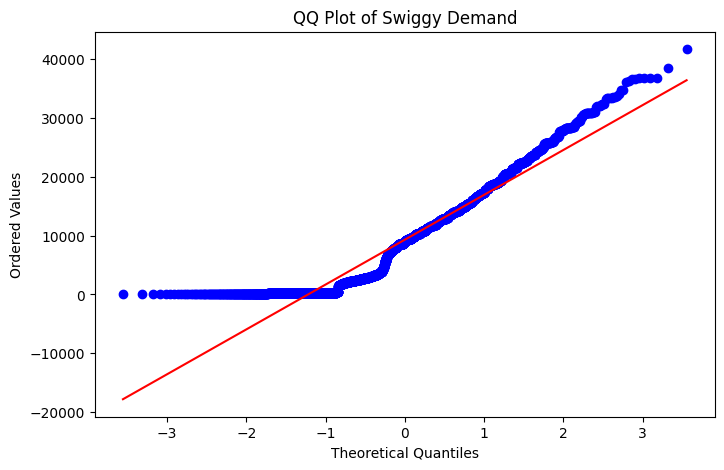

In [7]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# QQ Plot for Zomato demand
plt.figure(figsize=(8, 5))
stats.probplot(df['Zomato Demand'], dist="norm", plot=plt)
plt.title('QQ Plot of Zomato Demand')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

# QQ Plot for Swiggy demand
plt.figure(figsize=(8, 5))
stats.probplot(df['Swiggy Demand'], dist="norm", plot=plt)
plt.title('QQ Plot of Swiggy Demand')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()


Training Model 1/10 - Epochs: 50, Units: 128, Batch: 16, Dropout: 0.5, LR: 0.001, Layers: 3


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Model 2/10 - Epochs: 50, Units: 32, Batch: 32, Dropout: 0.5, LR: 0.01, Layers: 2
Training Model 3/10 - Epochs: 200, Units: 64, Batch: 64, Dropout: 0.4, LR: 0.005, Layers: 1
Training Model 4/10 - Epochs: 200, Units: 64, Batch: 64, Dropout: 0.5, LR: 0.01, Layers: 3
Training Model 5/10 - Epochs: 100, Units: 64, Batch: 16, Dropout: 0.2, LR: 0.01, Layers: 1
Training Model 6/10 - Epochs: 100, Units: 32, Batch: 16, Dropout: 0.1, LR: 0.01, Layers: 3
Training Model 7/10 - Epochs: 200, Units: 128, Batch: 16, Dropout: 0.4, LR: 0.01, Layers: 1
Training Model 8/10 - Epochs: 150, Units: 128, Batch: 32, Dropout: 0.4, LR: 0.01, Layers: 2
Training Model 9/10 - Epochs: 50, Units: 128, Batch: 32, Dropout: 0.5, LR: 0.005, Layers: 2
Training Model 10/10 - Epochs: 100, Units: 32, Batch: 16, Dropout: 0.4, LR: 0.01, Layers: 3


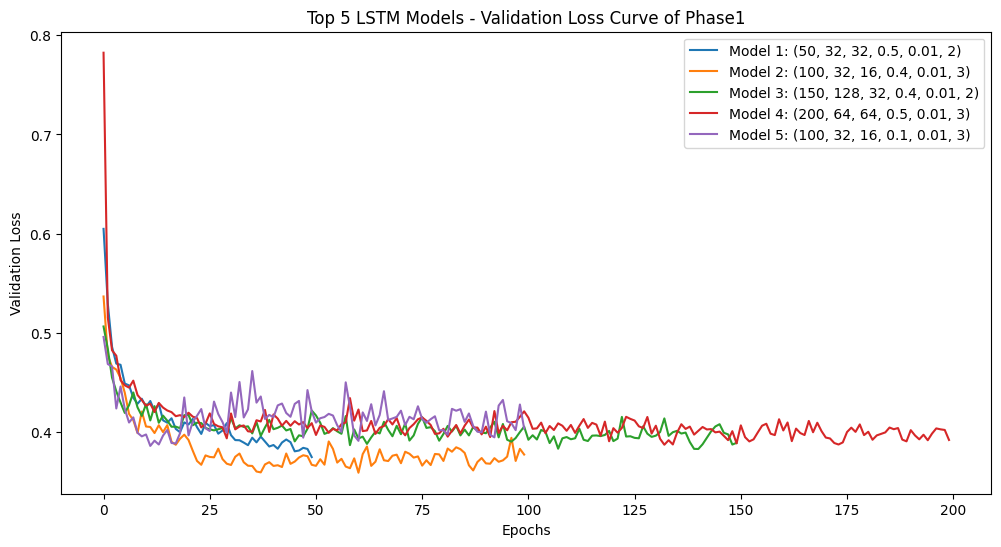

In [10]:
import itertools
import random
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Selecting Features and Target Variables
features = ["Zomato Price", "Swiggy Price", "Swiggy Lead Time", "holiday", "Event Importance", "weather", "economic_index"]
targets = ["Zomato Demand", "Swiggy Demand"]

# Convert categorical columns
df["holiday"] = df["holiday"].astype(int)
df["Event Importance"] = df["Event Importance"].astype("category").cat.codes
df["weather"] = df["weather"].astype("category").cat.codes

# Standardize features and targets separately
scaler_features = StandardScaler()
scaler_targets = StandardScaler()

df_scaled_features = scaler_features.fit_transform(df[features])
df_scaled_targets = scaler_targets.fit_transform(df[targets])

df_scaled = np.hstack((df_scaled_features, df_scaled_targets))

# Split Data (70% Train, 15% Validate, 15% Test)
n = len(df)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

df_train = df_scaled[:train_size]
df_val = df_scaled[train_size:train_size+val_size]
df_test = df_scaled[train_size+val_size:]

# Extract Dates for validation set
date_values = df["Date"].values
dates_val = date_values[train_size+5:train_size+5+len(df_val)-5]

# Function to Create Sequences
def create_sequences(data, sequence_length=5):
    X, y = [], []
    for i in range(len(data) - sequence_length - 5):
        X.append(data[i:i+sequence_length, :-2])  # Independent variables
        y.append(data[i+sequence_length:i+sequence_length+5, -2:])  # Dependent variables
    return np.array(X), np.array(y)

# Create sequences for training and validation
X_train, y_train = create_sequences(df_train)
X_val, y_val = create_sequences(df_val)

# Reshape target to match output layer
y_train = y_train.reshape(y_train.shape[0], 5, 2)
y_val = y_val.reshape(y_val.shape[0], 5, 2)

# Define Hyperparameter Grid
epochs_list = [50, 100, 150, 200]
units_list = [32, 64, 128]
batch_size_list = [16, 32, 64]
dropout_list = [0.1, 0.2, 0.3, 0.4, 0.5]
learning_rate_list = [0.001, 0.005, 0.01]
layers_list = [1, 2, 3]

# Generate Random Combinations
num_models_to_try =10  # Change this to try more models
param_combinations = list(itertools.product(epochs_list, units_list, batch_size_list, dropout_list, learning_rate_list, layers_list))
random.shuffle(param_combinations)  # Shuffle to randomize selection
param_combinations = param_combinations[:num_models_to_try]

# Dictionary to store results
results = {}

# Train multiple models with different hyperparameters
for idx, (epochs, units, batch_size, dropout, lr, layers) in enumerate(param_combinations):
    print(f"Training Model {idx+1}/{num_models_to_try} - Epochs: {epochs}, Units: {units}, Batch: {batch_size}, Dropout: {dropout}, LR: {lr}, Layers: {layers}")
    
    # Build LSTM Model
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(5, X_train.shape[2])))
    model.add(Dropout(dropout))
    
    for _ in range(layers - 1):  # Add extra layers if layers > 1
        model.add(LSTM(units // 2, return_sequences=True))
        model.add(Dropout(dropout))
    
    model.add(Dense(2))  # Output shape (batch_size, 5, 2)

    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')

    # Train Model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)

    # Store results
    results[(epochs, units, batch_size, dropout, lr, layers)] = history.history['val_loss'][-1], history.history  # Store final validation loss

# Select the best 5 models based on lowest validation loss
best_models = sorted(results.items(), key=lambda x: x[1][0])[:5]

# Plot Loss Curves for Best 5 Models
plt.figure(figsize=(12, 6))
for i, (params, (_, history)) in enumerate(best_models):
    plt.plot(history['val_loss'], label=f"Model {i+1}: {params}")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Top 5 LSTM Models - Validation Loss Curve of Phase1")
plt.legend()
plt.show()


In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load your DataFrame (df) here
# df = pd.read_csv("your_data.csv")  # Uncomment if loading from a file

# Selecting Features and Target Variables
features = ["Zomato Price", "Swiggy Price", "Swiggy Lead Time", "holiday", "Event Importance", "weather", "economic_index"]
targets = ["Zomato Demand", "Swiggy Demand"]

# Convert categorical columns
df["holiday"] = df["holiday"].astype(int)
df["Event Importance"] = df["Event Importance"].astype("category").cat.codes
df["weather"] = df["weather"].astype("category").cat.codes

# Function to remove outliers using the IQR method
def remove_outliers(df, columns, threshold=1.5):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Remove outliers from features and targets
df = remove_outliers(df, features + targets)

# Standardize features and targets separately
scaler_features = StandardScaler()
scaler_targets = StandardScaler()
df_scaled_features = scaler_features.fit_transform(df[features])
df_scaled_targets = scaler_targets.fit_transform(df[targets])

df_scaled = np.hstack((df_scaled_features, df_scaled_targets))

# Split Data (75% Train, 15% Validate, 10% Test)
n = len(df)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

df_train = df_scaled[:train_size]
df_val = df_scaled[train_size:train_size+val_size]
df_test = df_scaled[train_size+val_size:]
# Extract Dates for validation set properly
date_values = df["Date"].values

# Function to Create Sequences with Proper Date Alignment
def create_sequences(data, dates, sequence_length=5):
    X, y, seq_dates = [], [], []
    for i in range(len(data) - sequence_length - 5):
        X.append(data[i:i+sequence_length, :-2])  # Features
        y.append(data[i+sequence_length:i+sequence_length+5, -2:])  # Targets
        seq_dates.append(dates[i+sequence_length])  # Aligned validation dates
    return np.array(X), np.array(y), np.array(seq_dates)

# Create sequences for train and validation
X_train, y_train, _ = create_sequences(df_train, date_values[:train_size])
X_val, y_val, dates_val = create_sequences(df_val, date_values[train_size:train_size+val_size])

# Reshape target to match output layer
y_train = y_train.reshape(y_train.shape[0], 5, 2)
y_val = y_val.reshape(y_val.shape[0], 5, 2)

# Build LSTM Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(5, X_train.shape[2])),
    Dropout(0.1),
    LSTM(32, return_sequences=True),
    Dropout(0.1),
    LSTM(32, return_sequences=True),
    Dropout(0.1),
    Dense(2)  # Output shape (batch_size, 5, 2)
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train Model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val))

# Predict on Validation Set
y_pred = model.predict(X_val)

# Convert predictions back to original scale
y_test_original = scaler_targets.inverse_transform(y_val.reshape(-1, 2)).reshape(y_val.shape)
y_pred_original = scaler_targets.inverse_transform(y_pred.reshape(-1, 2)).reshape(y_pred.shape)


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.9722 - val_loss: 1.0359
Epoch 2/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.8972 - val_loss: 0.9950
Epoch 3/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.8485 - val_loss: 1.0133
Epoch 4/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.7948 - val_loss: 1.0413
Epoch 5/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.7220 - val_loss: 1.0964
Epoch 6/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.6565 - val_loss: 1.1074
Epoch 7/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.5950 - val_loss: 1.1025
Epoch 8/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5311 - val_loss: 1.1223
Epoch 9/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.4841 - val_loss: 1.2073
Epoch 10/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.4436 - val_loss: 1.1490
Epoch 11/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.4283 - val_loss: 1.1800
Epoch 12/100
146/146 ━━━━━━━━

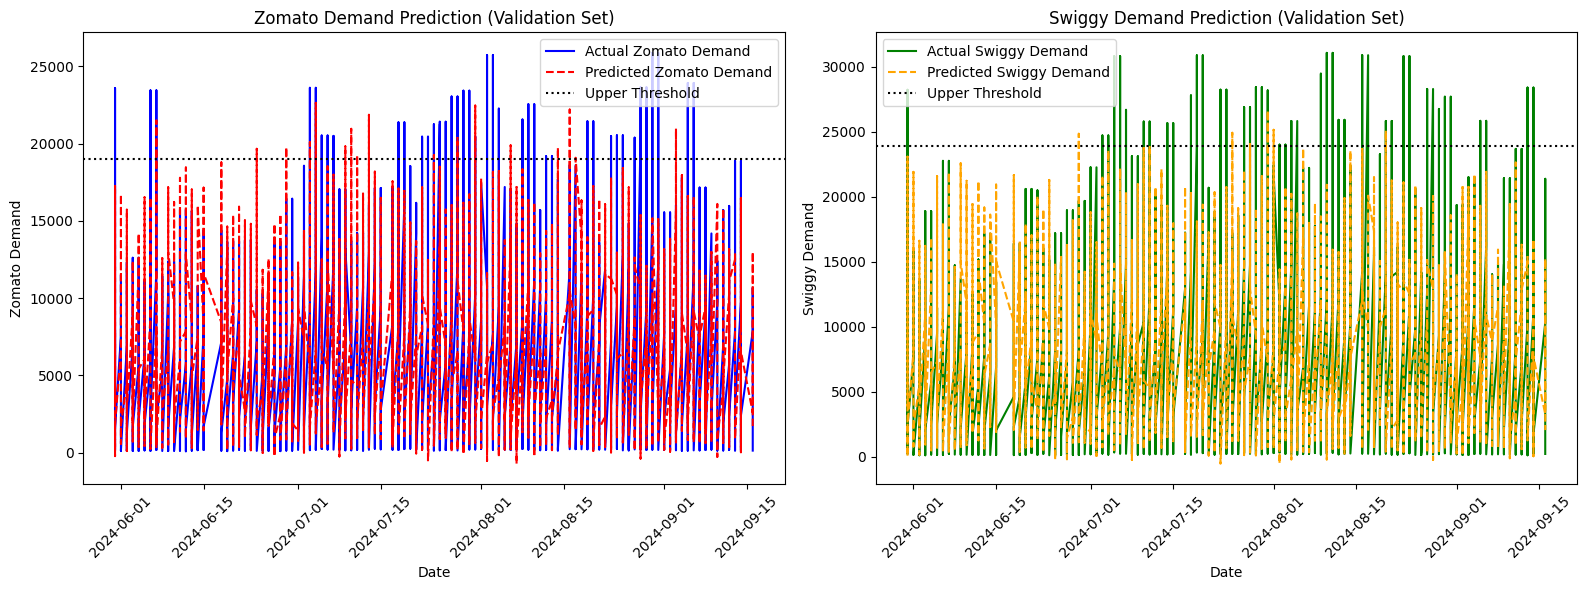

In [10]:
# Repeat each date 5 times to match y_val_original and y_pred_original
dates_test_repeated = np.repeat(dates_val, 5)

# Calculate Upper Threshold (95th percentile) for demand values
zomato_threshold = np.percentile(y_test_original[:, :, 0], 95)
swiggy_threshold = np.percentile(y_test_original[:, :, 1], 95)

# Create subplots for test results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Zomato Demand for Test Set with Upper Threshold Line
axes[0].plot(dates_test_repeated, y_test_original[:, :, 0].flatten(), label="Actual Zomato Demand", color='blue')
axes[0].plot(dates_test_repeated, y_pred_original[:, :, 0].flatten(), label="Predicted Zomato Demand", linestyle='dashed', color='red')
axes[0].axhline(y=zomato_threshold, color='black', linestyle='dotted', label="Upper Threshold")  # Upper threshold line
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Zomato Demand")
axes[0].legend()
axes[0].set_title("Zomato Demand Prediction (Validation Set)")
axes[0].tick_params(axis='x', rotation=45)

# Plot Swiggy Demand for Test Set with Upper Threshold Line
axes[1].plot(dates_test_repeated, y_test_original[:, :, 1].flatten(), label="Actual Swiggy Demand", color='green')
axes[1].plot(dates_test_repeated, y_pred_original[:, :, 1].flatten(), label="Predicted Swiggy Demand", linestyle='dashed', color='orange')
axes[1].axhline(y=swiggy_threshold, color='black', linestyle='dotted', label="Upper Threshold")  # Upper threshold line
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Swiggy Demand")
axes[1].legend()
axes[1].set_title("Swiggy Demand Prediction (Validation Set)")
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout for clarity
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 0.9289 - val_loss: 0.7919
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.7039 - val_loss: 0.7543
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.6294 - val_loss: 0.7317
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.5759 - val_loss: 0.7099
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.5436 - val_loss: 0.7329
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.5157 - val_loss: 0.7179
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.4833 - val_loss: 0.7654
Epoch 8/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.4433 - val_loss: 0.7861
Epoch 9/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.4112 - val_loss: 0.8094
Epoch 10/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.3864 - val_loss: 0.8375
Epoch 11/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.3774 - val_loss: 0.8146
Epoch 12/100
174/174 ━━━━━━━━

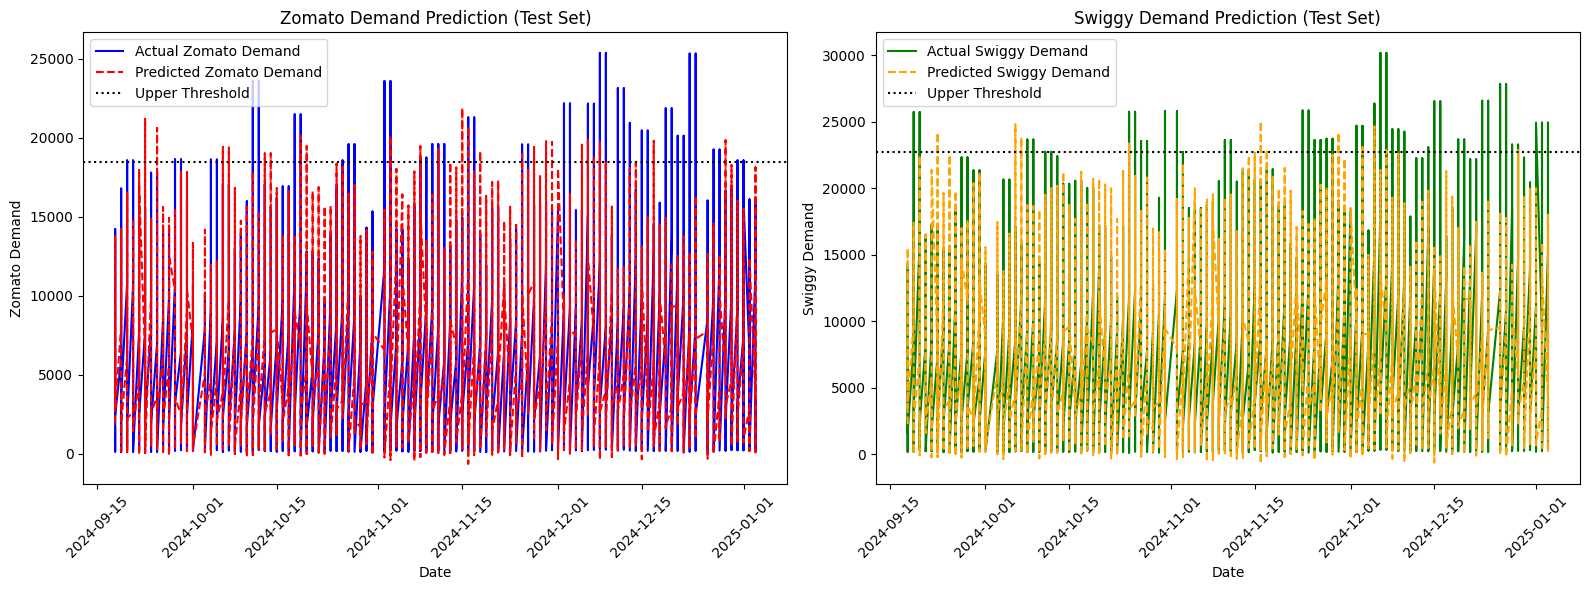

In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load your DataFrame (df) here
# df = pd.read_csv("your_data.csv")  # Uncomment if loading from a file

# Selecting Features and Target Variables
features = ["Zomato Price", "Swiggy Price", "Swiggy Lead Time", "holiday", "Event Importance", "weather", "economic_index"]
targets = ["Zomato Demand", "Swiggy Demand"]

# Convert categorical columns
df["holiday"] = df["holiday"].astype(int)
df["Event Importance"] = df["Event Importance"].astype("category").cat.codes
df["weather"] = df["weather"].astype("category").cat.codes

# Function to remove outliers using the IQR method
def remove_outliers(df, columns, threshold=1.5):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Remove outliers from features and targets
df = remove_outliers(df, features + targets)

# Standardize features and targets separately
scaler_features = StandardScaler()
scaler_targets = StandardScaler()
df_scaled_features = scaler_features.fit_transform(df[features])
df_scaled_targets = scaler_targets.fit_transform(df[targets])

df_scaled = np.hstack((df_scaled_features, df_scaled_targets))

# Split Data (85% Train, 10% Test)
n = len(df)
train_size = int(n * 0.85)
test_size = n - train_size

df_train = df_scaled[:train_size]
df_test = df_scaled[train_size:]

# Extract Dates for proper alignment
date_values = df["Date"].values

# Function to Create Sequences
def create_sequences(data, dates, sequence_length=5):
    X, y, seq_dates = [], [], []
    for i in range(len(data) - sequence_length - 5):
        X.append(data[i:i+sequence_length, :-2])  # Features
        y.append(data[i+sequence_length:i+sequence_length+5, -2:])  # Targets
        seq_dates.append(dates[i+sequence_length])  # Aligned validation dates
    return np.array(X), np.array(y), np.array(seq_dates)

# Create sequences for train and test
X_train, y_train, _ = create_sequences(df_train, date_values[:train_size])
X_test, y_test, dates_test = create_sequences(df_test, date_values[train_size:])

# Reshape target to match output layer
y_train = y_train.reshape(y_train.shape[0], 5, 2)
y_test = y_test.reshape(y_test.shape[0], 5, 2)

# Build LSTM Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(5, X_train.shape[2])),
    Dropout(0.1),
    LSTM(32, return_sequences=True),
    Dropout(0.1),
    LSTM(32, return_sequences=True),
    Dropout(0.1),
    Dense(2)  # Output shape (batch_size, 5, 2)
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train Model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))

# Predict on Test Set
y_pred = model.predict(X_test)

# Convert predictions back to original scale
y_test_original = scaler_targets.inverse_transform(y_test.reshape(-1, 2)).reshape(y_test.shape)
y_pred_original = scaler_targets.inverse_transform(y_pred.reshape(-1, 2)).reshape(y_pred.shape)
# Repeat each date 5 times to match y_test_original and y_pred_original
dates_test_repeated = np.repeat(dates_test, 5)

# Calculate Upper Threshold (95th percentile) for demand values
zomato_threshold = np.percentile(y_test_original[:, :, 0], 95)
swiggy_threshold = np.percentile(y_test_original[:, :, 1], 95)

# Create subplots for test results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Zomato Demand for Test Set with Upper Threshold Line
axes[0].plot(dates_test_repeated, y_test_original[:, :, 0].flatten(), label="Actual Zomato Demand", color='blue')
axes[0].plot(dates_test_repeated, y_pred_original[:, :, 0].flatten(), label="Predicted Zomato Demand", linestyle='dashed', color='red')
axes[0].axhline(y=zomato_threshold, color='black', linestyle='dotted', label="Upper Threshold")  # Upper threshold line
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Zomato Demand")
axes[0].legend()
axes[0].set_title("Zomato Demand Prediction (Test Set)")
axes[0].tick_params(axis='x', rotation=45)

# Plot Swiggy Demand for Test Set with Upper Threshold Line
axes[1].plot(dates_test_repeated, y_test_original[:, :, 1].flatten(), label="Actual Swiggy Demand", color='green')
axes[1].plot(dates_test_repeated, y_pred_original[:, :, 1].flatten(), label="Predicted Swiggy Demand", linestyle='dashed', color='orange')
axes[1].axhline(y=swiggy_threshold, color='black', linestyle='dotted', label="Upper Threshold")  # Upper threshold line
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Swiggy Demand")
axes[1].legend()
axes[1].set_title("Swiggy Demand Prediction (Test Set)")
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout for clarity
plt.tight_layout()
plt.show()


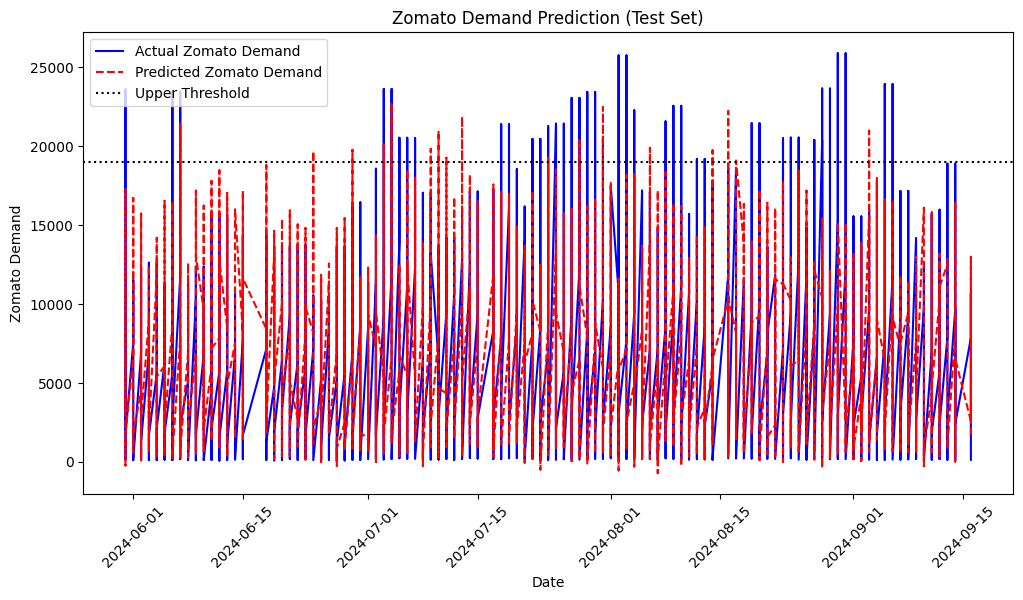

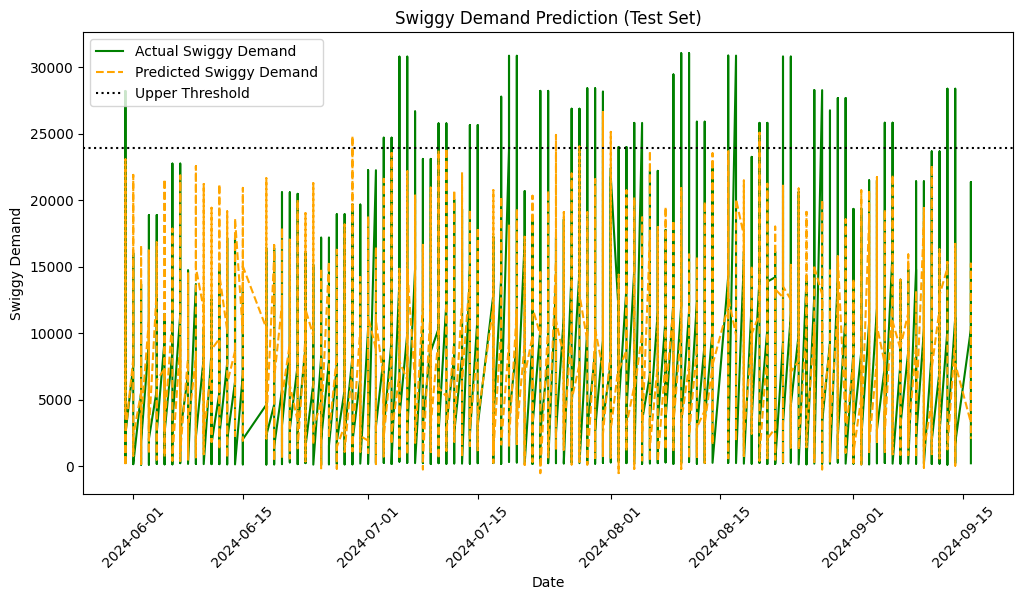

In [12]:

# Plot Zomato Demand for Test Set
plt.figure(figsize=(12, 6))  # Stretched figure size
plt.plot(dates_test_repeated, y_test_original[:, :, 0].flatten(), label="Actual Zomato Demand", color='blue')
plt.plot(dates_test_repeated, y_pred_original[:, :, 0].flatten(), label="Predicted Zomato Demand", linestyle='dashed', color='red')
plt.axhline(y=zomato_threshold, color='black', linestyle='dotted', label="Upper Threshold")  # Upper threshold line
plt.xlabel("Date")
plt.ylabel("Zomato Demand")
plt.legend()
plt.title("Zomato Demand Prediction (Test Set)")
plt.xticks(rotation=45)
plt.show()

# Plot Swiggy Demand for Test Set
plt.figure(figsize=(12, 6))  # Stretched figure size
plt.plot(dates_test_repeated, y_test_original[:, :, 1].flatten(), label="Actual Swiggy Demand", color='green')
plt.plot(dates_test_repeated, y_pred_original[:, :, 1].flatten(), label="Predicted Swiggy Demand", linestyle='dashed', color='orange')
plt.axhline(y=swiggy_threshold, color='black', linestyle='dotted', label="Upper Threshold")  # Upper threshold line
plt.xlabel("Date")
plt.ylabel("Swiggy Demand")
plt.legend()
plt.title("Swiggy Demand Prediction (Test Set)")
plt.xticks(rotation=45)
plt.show()


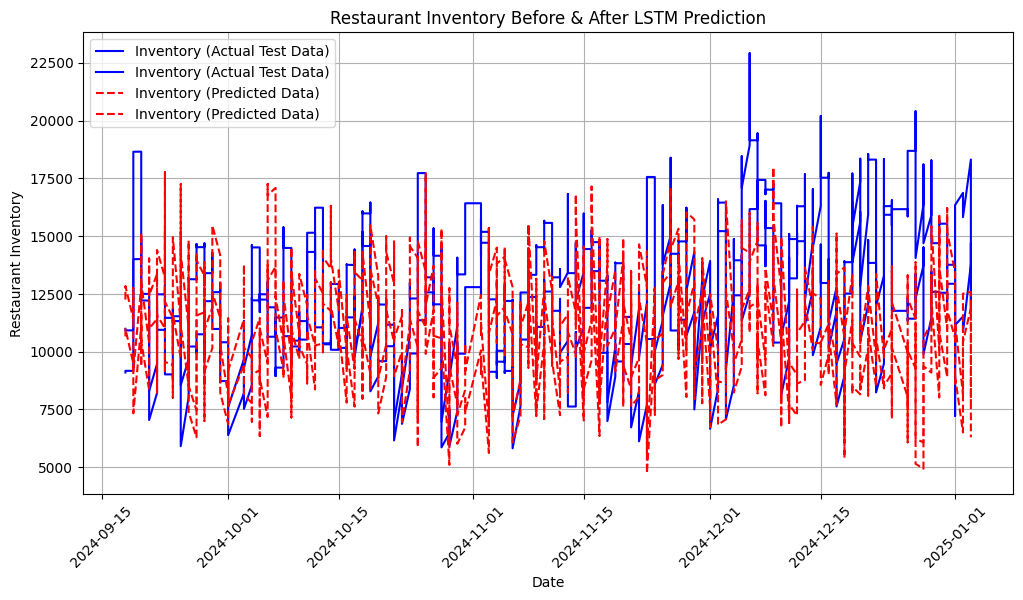

In [8]:
import matplotlib.pyplot as plt

def calculate_newsvendor_inventory(demand, std_dev, z_value=0.68):
    """
    Calculate optimal restaurant inventory based on demand and standard deviation.
    :param demand: Mean demand value
    :param std_dev: Standard deviation of demand
    :param z_value: Z-score to ensure safety stock (default ~90% service level)
    :return: Computed inventory level
    """
    return np.round(demand + z_value * std_dev)

# Compute Mean & Std Dev from Test Data
test_demand_mean = np.mean(y_test_original, axis=1)  # Mean demand per day
test_demand_std = np.std(y_test_original, axis=1)    # Std dev per day

# Compute Mean & Std Dev from Predicted Data
pred_demand_mean = np.mean(y_pred_original, axis=1)  # Mean demand per day
pred_demand_std = np.std(y_pred_original, axis=1)    # Std dev per day

# Calculate Restaurant Inventory for Test & Predicted Demand
restaurant_inventory_test = calculate_newsvendor_inventory(test_demand_mean, test_demand_std)
restaurant_inventory_pred = calculate_newsvendor_inventory(pred_demand_mean, pred_demand_std)

# Plot Inventory Levels
plt.figure(figsize=(12, 6))
plt.plot(dates_test, restaurant_inventory_test, label="Inventory (Actual Test Data)", color='blue')
plt.plot(dates_test, restaurant_inventory_pred, label="Inventory (Predicted Data)", linestyle='dashed', color='red')

plt.xlabel("Date")
plt.ylabel("Restaurant Inventory")
plt.title("Restaurant Inventory Before & After LSTM Prediction")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()


Legend Labels: ['Actual Inventory', 'Actual Inventory', 'Predicted Inventory', 'Predicted Inventory']


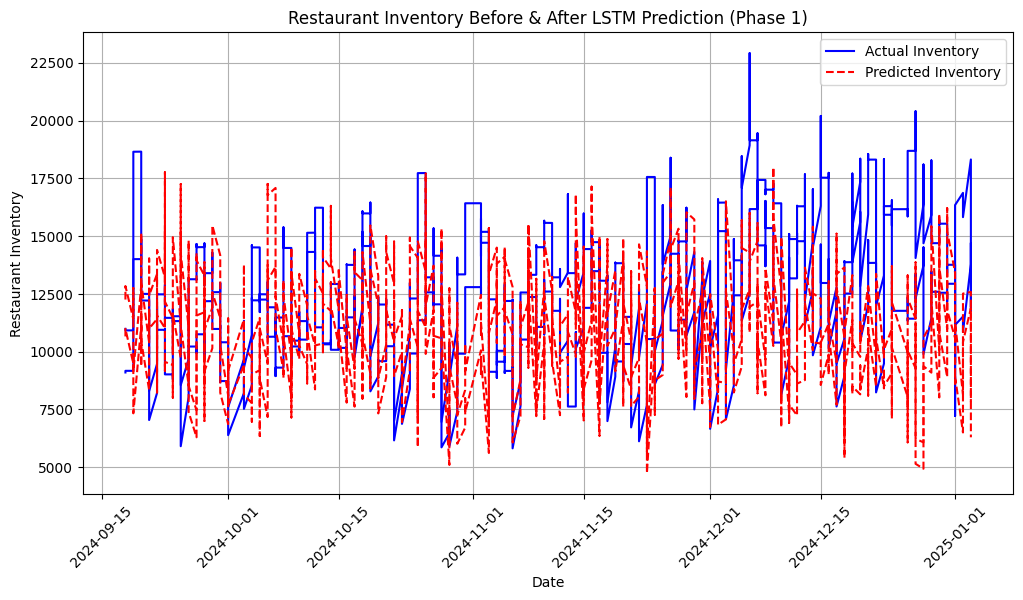

In [9]:
plt.figure(figsize=(12, 6))

# Plotting actual and predicted inventory
plt.plot(dates_test, restaurant_inventory_test, label="Actual Inventory", color='blue', linestyle='solid')
plt.plot(dates_test, restaurant_inventory_pred, label="Predicted Inventory", color='red', linestyle='dashed')

plt.xlabel("Date")
plt.ylabel("Restaurant Inventory")
plt.title("Restaurant Inventory Before & After LSTM Prediction (Phase 1)")
plt.xticks(rotation=45)
plt.grid()

# Debug: Print existing legend labels
handles, labels = plt.gca().get_legend_handles_labels()
print("Legend Labels:", labels)  # Check for duplicates

# Remove duplicate labels before setting legend
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys())

plt.show()


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Function to compute evaluation metrics
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Reshape for evaluation (flatten the sequences)
y_test_zomato = y_test_original[:, :, 0].flatten()
y_pred_zomato = y_pred_original[:, :, 0].flatten()
y_test_swiggy = y_test_original[:, :, 1].flatten()
y_pred_swiggy = y_pred_original[:, :, 1].flatten()

# Compute metrics for Zomato demand
rmse_zomato, mae_zomato, r2_zomato = evaluate_model(y_test_zomato, y_pred_zomato)

# Compute metrics for Swiggy demand
rmse_swiggy, mae_swiggy, r2_swiggy = evaluate_model(y_test_swiggy, y_pred_swiggy)

# Print results
print("Evaluation Metrics:")
print(f"Zomato - RMSE: {rmse_zomato:.2f}, MAE: {mae_zomato:.2f}, R²: {r2_zomato:.4f}")
print(f"Swiggy - RMSE: {rmse_swiggy:.2f}, MAE: {mae_swiggy:.2f}, R²: {r2_swiggy:.4f}")


Evaluation Metrics:
Zomato - RMSE: 5531.67, MAE: 4130.31, R²: 0.1914
Swiggy - RMSE: 6768.82, MAE: 4992.76, R²: 0.1773


In [13]:
# Function to calculate Bullwhip Effect
def calculate_bullwhip(inventory, demand):
    return np.var(inventory) / np.var(demand)

# Extract restaurant inventory from dataset (Assuming it's in the original df)
train_inventory = df["Restaurant Inventory"][:train_size].values
test_inventory = df["Restaurant Inventory"][train_size:].values

# Compute Bullwhip Effect for Training Data
bullwhip_train_zomato = calculate_bullwhip(train_inventory, df["Zomato Demand"][:train_size].values)
bullwhip_train_swiggy = calculate_bullwhip(train_inventory, df["Swiggy Demand"][:train_size].values)
bullwhip_train_overall = (bullwhip_train_zomato + bullwhip_train_swiggy) / 2

# Compute Bullwhip Effect for Testing Data
bullwhip_test_zomato = calculate_bullwhip(test_inventory, df["Zomato Demand"][train_size:].values)
bullwhip_test_swiggy = calculate_bullwhip(test_inventory, df["Swiggy Demand"][train_size:].values)
bullwhip_test_overall = (bullwhip_test_zomato + bullwhip_test_swiggy) / 2

# Compute Bullwhip Effect for Predicted Data (Use Predicted Inventory)
bullwhip_pred_zomato = calculate_bullwhip(restaurant_inventory_pred, y_pred_original[:, :, 0].flatten())
bullwhip_pred_swiggy = calculate_bullwhip(restaurant_inventory_pred, y_pred_original[:, :, 1].flatten())
bullwhip_pred_overall = (bullwhip_pred_zomato + bullwhip_pred_swiggy) / 2

# Print results
print("\nBullwhip Effect Results:")
print(f"Training - Zomato: {bullwhip_train_zomato:.2f}, Swiggy: {bullwhip_train_swiggy:.2f}, Overall: {bullwhip_train_overall:.2f}")
print(f"Testing  - Zomato: {bullwhip_test_zomato:.2f}, Swiggy: {bullwhip_test_swiggy:.2f}, Overall: {bullwhip_test_overall:.2f}")
print(f"Predicted - Zomato: {bullwhip_pred_zomato:.2f}, Swiggy: {bullwhip_pred_swiggy:.2f}, Overall: {bullwhip_pred_overall:.2f}")



Bullwhip Effect Results:
Training - Zomato: 6.06, Swiggy: 4.17, Overall: 5.11
Testing  - Zomato: 5.74, Swiggy: 3.90, Overall: 4.82
Predicted - Zomato: 0.26, Swiggy: 0.18, Overall: 0.22


Legend Labels: ['Actual Demand', 'Actual Inventory (Before LSTM)', 'Actual Inventory (Before LSTM)']


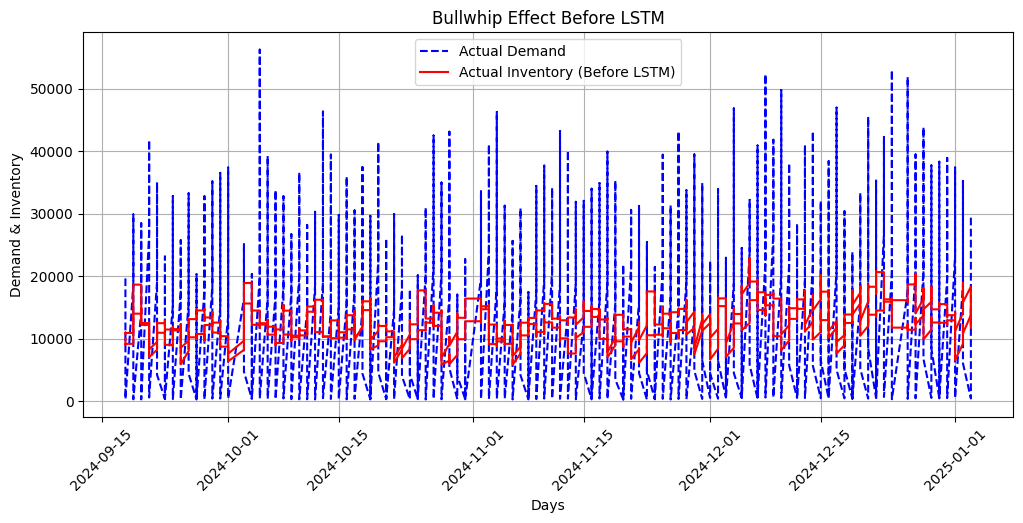

Legend Labels: ['Predicted Demand', 'Predicted Inventory (After LSTM)', 'Predicted Inventory (After LSTM)']


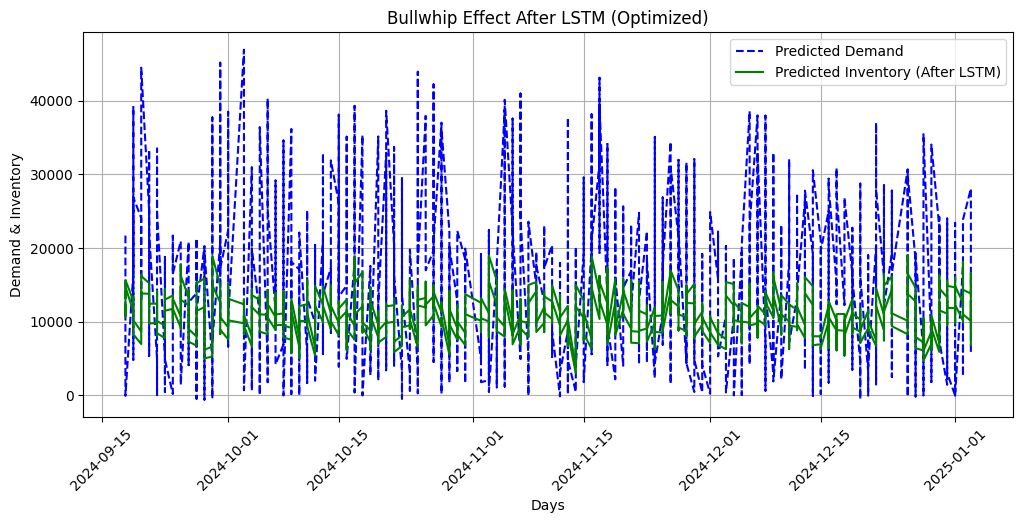

In [18]:
# Trim Swiggy and Zomato demand to match the length of dates_test
swiggy_demand = df["Swiggy Demand"][train_size:train_size+491]
zomato_demand = df["Zomato Demand"][train_size:train_size+491]
# Compute predicted demand (sum across Swiggy & Zomato predictions)
predicted_demand = y_pred_original[:, :, 0].flatten() + y_pred_original[:, :, 1].flatten()

# Ensure predicted demand has the same length as other test data
predicted_demand = predicted_demand[:491]

# 📌 PLOT 1: Actual Demand vs. Actual Inventory (Before LSTM)
plt.figure(figsize=(12, 5))
plt.plot(dates_test, swiggy_demand + zomato_demand, label="Actual Demand", linestyle="dashed", color="blue")
plt.plot(dates_test, restaurant_inventory_test, label="Actual Inventory (Before LSTM)", color="red")
plt.xlabel("Days")
plt.ylabel("Demand & Inventory")
plt.title("Bullwhip Effect Before LSTM")
plt.xticks(rotation=45)
plt.grid()
# Debug: Print existing legend labels
handles, labels = plt.gca().get_legend_handles_labels()
print("Legend Labels:", labels)  # Check for duplicates

# Remove duplicate labels before setting legend
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys())

plt.show()

# 📌 PLOT 2: Predicted Demand vs. Predicted Inventory (After LSTM)
plt.figure(figsize=(12, 5))
plt.plot(dates_test, predicted_demand, label="Predicted Demand", linestyle="dashed", color="blue")
plt.plot(dates_test, restaurant_inventory_pred, label="Predicted Inventory (After LSTM)", color="green")
plt.xlabel("Days")
plt.ylabel("Demand & Inventory")
plt.title("Bullwhip Effect After LSTM (Optimized)")
plt.xticks(rotation=45)
plt.grid()
# Debug: Print existing legend labels
handles, labels = plt.gca().get_legend_handles_labels()
print("Legend Labels:", labels)  # Check for duplicates

# Remove duplicate labels before setting legend
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys())

plt.show()


Training Model 1/10 - Epochs: 50, Units: 128, Batch: 16, Dropout: 0.5, LR: 0.001, Layers: 3


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Model 2/10 - Epochs: 50, Units: 32, Batch: 32, Dropout: 0.5, LR: 0.01, Layers: 2
Training Model 3/10 - Epochs: 200, Units: 64, Batch: 64, Dropout: 0.4, LR: 0.005, Layers: 1
Training Model 4/10 - Epochs: 200, Units: 64, Batch: 64, Dropout: 0.5, LR: 0.01, Layers: 3
Training Model 5/10 - Epochs: 100, Units: 64, Batch: 16, Dropout: 0.2, LR: 0.01, Layers: 1
Training Model 6/10 - Epochs: 100, Units: 32, Batch: 16, Dropout: 0.1, LR: 0.01, Layers: 3
Training Model 7/10 - Epochs: 200, Units: 128, Batch: 16, Dropout: 0.4, LR: 0.01, Layers: 1
Training Model 8/10 - Epochs: 150, Units: 128, Batch: 32, Dropout: 0.4, LR: 0.01, Layers: 2
Training Model 9/10 - Epochs: 50, Units: 128, Batch: 32, Dropout: 0.5, LR: 0.005, Layers: 2
Training Model 10/10 - Epochs: 100, Units: 32, Batch: 16, Dropout: 0.4, LR: 0.01, Layers: 3


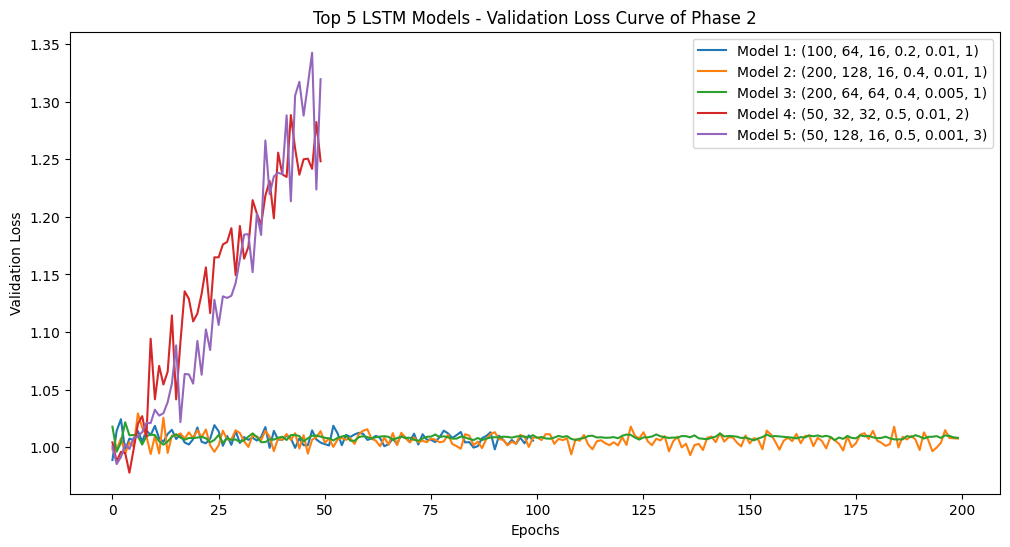

In [4]:
import itertools
import random
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.optimizers import Adam

# Assuming df is already loaded
# Convert categorical columns
df["holiday"] = df["holiday"].astype(int)
df["Event Importance"] = df["Event Importance"].astype("category").cat.codes
df["weather"] = df["weather"].astype("category").cat.codes

# Group by 'date' and calculate the mean of all columns
df = df.groupby('Date').agg({
    'Zomato Demand': 'mean',
    'Swiggy Demand': 'mean',
    'Zomato Price': 'mean',
    'Zomato Lead Time': 'mean',
    'Swiggy Price': 'mean',
    'Swiggy Lead Time': 'mean',
    'holiday': 'mean',  
    'Event Importance': 'mean',  
    'weather': 'mean',
    'economic_index': 'mean'
}).reset_index()

# Selecting Features and Target Variables
features = ["Zomato Price", "Swiggy Price", "Swiggy Lead Time", "holiday", "Event Importance", "weather", "economic_index"]
targets = ["Zomato Demand", "Swiggy Demand"]

# Standardize features and targets separately
scaler_features = StandardScaler()
scaler_targets = StandardScaler()

df_scaled_features = scaler_features.fit_transform(df[features])
df_scaled_targets = scaler_targets.fit_transform(df[targets])

df_scaled = np.hstack((df_scaled_features, df_scaled_targets))

# Split Data (70% Train, 15% Validate, 15% Test)
n = len(df)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

df_train = df_scaled[:train_size]
df_val = df_scaled[train_size:train_size+val_size]
df_test = df_scaled[train_size+val_size:]

# Extract Dates for validation set
date_values = df["Date"].values
dates_val = date_values[train_size+5:train_size+5+len(df_val)-5]

# Function to create sequences
def create_dataset(data, time_step=7):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step])
        y.append(data[i + time_step, :2])  # Only demand columns
    return np.array(X), np.array(y)

# Creating train and validation datasets
X_train, y_train = create_dataset(df_train, time_step=7)
X_val, y_val = create_dataset(df_val, time_step=7)

# Reshape target to match output layer
y_train = y_train.reshape(y_train.shape[0], 1, 2)
y_val = y_val.reshape(y_val.shape[0], 1, 2)

# Define Hyperparameter Grid
epochs_list = [50, 100, 150, 200]
units_list = [32, 64, 128]
batch_size_list = [16, 32, 64]
dropout_list = [0.1, 0.2, 0.3, 0.4, 0.5]
learning_rate_list = [0.001, 0.005, 0.01]
layers_list = [1, 2, 3]

# Generate Random Combinations
num_models_to_try = 10  
param_combinations = list(itertools.product(epochs_list, units_list, batch_size_list, dropout_list, learning_rate_list, layers_list))
random.shuffle(param_combinations)  
param_combinations = param_combinations[:num_models_to_try]

# Dictionary to store results
results = {}

# Train multiple models with different hyperparameters
for idx, (epochs, units, batch_size, dropout, lr, layers) in enumerate(param_combinations):
    print(f"Training Model {idx+1}/{num_models_to_try} - Epochs: {epochs}, Units: {units}, Batch: {batch_size}, Dropout: {dropout}, LR: {lr}, Layers: {layers}")
    
    # Build LSTM Model
    model = Sequential()
    model.add(LSTM(units, return_sequences=(layers > 1), input_shape=(7, X_train.shape[2])))
    model.add(Dropout(dropout))
    
    for _ in range(layers - 1):  
        model.add(LSTM(units // 2, return_sequences=True))
        model.add(Dropout(dropout))
    
    model.add(Dense(2))  # Time-distributed layer for sequence output

    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')

    # Train Model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)

    # Store results
    results[(epochs, units, batch_size, dropout, lr, layers)] = history.history['val_loss'][-1], history.history  

# Select the best 5 models based on lowest validation loss
best_models = sorted(results.items(), key=lambda x: x[1][0])[:5]

# Plot Loss Curves for Best 5 Models
plt.figure(figsize=(12, 6))
for i, (params, (_, history)) in enumerate(best_models):
    plt.plot(history['val_loss'], label=f"Model {i+1}: {params}")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Top 5 LSTM Models - Validation Loss Curve of Phase 2")
plt.legend()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_20764\3038168671.py:10: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.9867
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8385
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8577
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8701
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8451
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8015
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.7906
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.8153
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.8180 
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.7843
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.7529
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.7424
Epoch 13/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.7829
Epoch 14/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.7160
Epoch 15/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - l

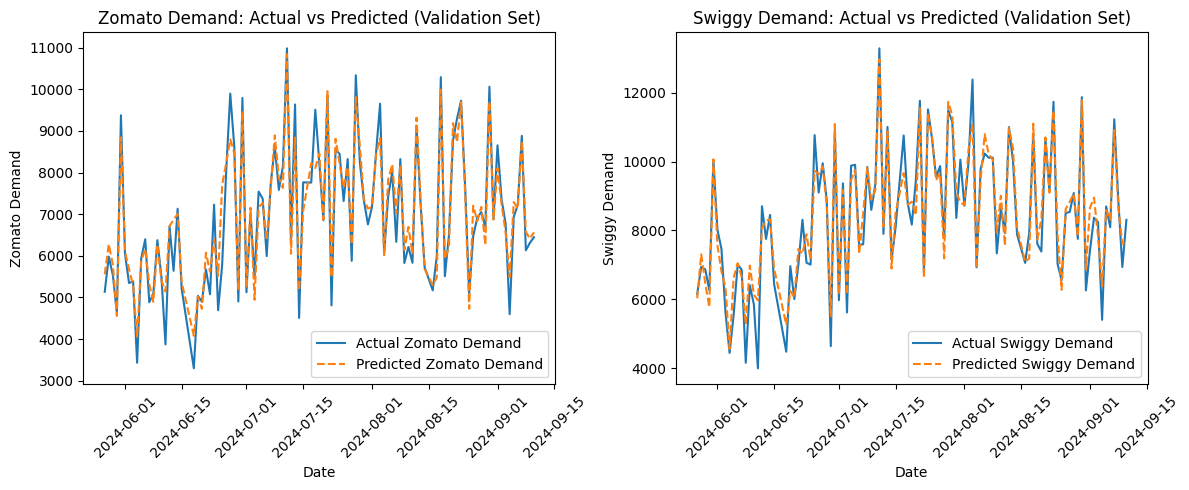

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error
import matplotlib.dates as mdates
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2

# Load and preprocess data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Encode categorical variables
df['holiday'] = df['holiday'].apply(lambda x: 0 if x == 'No' else 1)
event_encoder = LabelEncoder()
df['Event_Label'] = event_encoder.fit_transform(df['event'])
df['time_Label'] = event_encoder.fit_transform(df['Time'])
df['weather_Label'] = event_encoder.fit_transform(df['weather'])

# Function to remove outliers using IQR
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

columns_to_check = ['Zomato Demand', 'Swiggy Demand', 'Zomato Price', 'Zomato Lead Time', 'Swiggy Price', 'Swiggy Lead Time']
df_clean = remove_outliers(df, columns_to_check)

# Group by date and calculate daily averages
daily_avg = df_clean.groupby('Date').agg({
    'Zomato Demand': 'mean',
    'Swiggy Demand': 'mean',
    'Zomato Price': 'mean',
    'Zomato Lead Time': 'mean',
    'Swiggy Price': 'mean',
    'Swiggy Lead Time': 'mean',
    'holiday': 'mean',
    'Event_Label': 'mean',
    'time_Label': 'mean',
    'weather_Label': 'mean'
}).reset_index()

# Scaling
demand_scaler = StandardScaler()
feature_scaler = StandardScaler()

scaled_demand = demand_scaler.fit_transform(daily_avg[['Zomato Demand', 'Swiggy Demand']])
scaled_features = feature_scaler.fit_transform(daily_avg.drop(columns=['Date', 'Zomato Demand', 'Swiggy Demand']))

scaled_data = np.hstack([scaled_demand, scaled_features])

# Function to create dataset for LSTM
def create_dataset(data, time_step=7):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step])
        y.append(data[i + time_step, :2])  # Only demand columns
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, time_step=7)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

# Split dataset: 70% training, 15% validation, 15% testing
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, X_temp = X[:train_size], X[train_size:]
y_train, y_temp = y[:train_size], y[train_size:]

X_val, X_test = X_temp[:val_size], X_temp[val_size:]
y_val, y_test = y_temp[:val_size], y_temp[val_size:]
time_step = 7  # This should match the time step used in create_dataset function
features = X.shape[2]  # Extract number of features from the reshaped dataset

# LSTM Model
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, kernel_regularizer=l2(0.001), input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(2)  # Predicting both Zomato and Swiggy demand
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

model = create_lstm_model((X.shape[1], X.shape[2]))
model.fit(X, y, epochs=100, batch_size=16, verbose=1)


# Predict on Validation Set using the best model
predictions_val = model.predict(X_val)
predicted_demand_val = demand_scaler.inverse_transform(predictions_val)
actual_demand_val = demand_scaler.inverse_transform(y_val)

# Visualization for entire validation set
plt.figure(figsize=(12, 5))

# Get all validation set dates
validation_dates = daily_avg['Date'].iloc[train_size:train_size + val_size].values

plt.subplot(1, 2, 1)
plt.plot(validation_dates, actual_demand_val[:, 0], label='Actual Zomato Demand')
plt.plot(validation_dates, predicted_demand_val[:, 0], label='Predicted Zomato Demand', linestyle='--')
plt.title('Zomato Demand: Actual vs Predicted (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Zomato Demand')
plt.legend()
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(validation_dates, actual_demand_val[:, 1], label='Actual Swiggy Demand')
plt.plot(validation_dates, predicted_demand_val[:, 1], label='Predicted Swiggy Demand', linestyle='--')
plt.title('Swiggy Demand: Actual vs Predicted (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Swiggy Demand')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

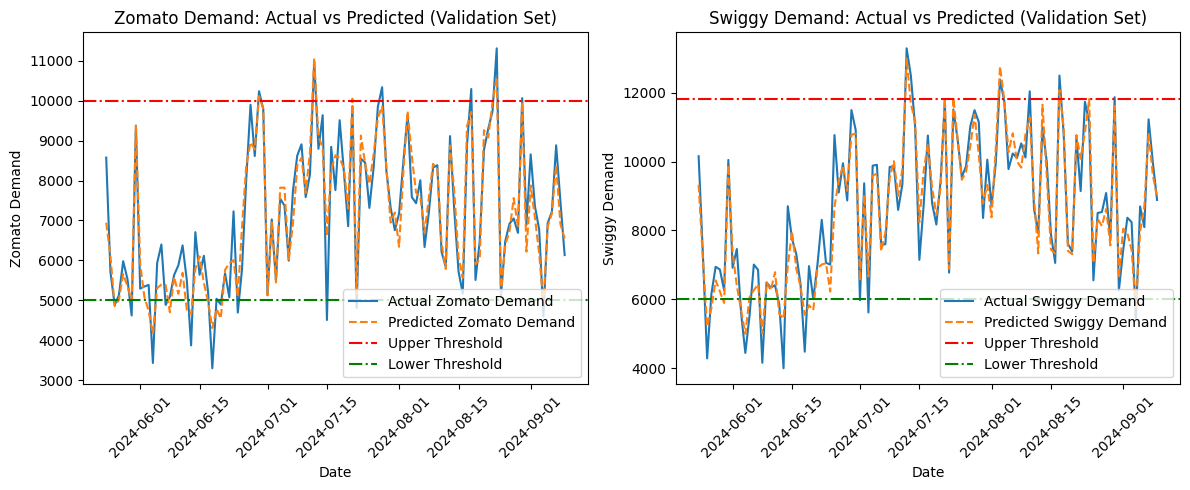

In [6]:
# Compute threshold values dynamically
zomato_upper_threshold = np.percentile(actual_demand_val[:, 0], 95)  # 95th percentile
zomato_lower_threshold = np.percentile(actual_demand_val[:, 0], 10)  # 10th percentile

swiggy_upper_threshold = np.percentile(actual_demand_val[:, 1], 95)  # 95th percentile
swiggy_lower_threshold = np.percentile(actual_demand_val[:, 1], 10)  # 10th percentile

plt.figure(figsize=(12, 5))

# Zomato Demand Plot
plt.subplot(1, 2, 1)
plt.plot(validation_dates, actual_demand_val[:, 0], label='Actual Zomato Demand')
plt.plot(validation_dates, predicted_demand_val[:, 0], label='Predicted Zomato Demand', linestyle='--')
plt.axhline(y=zomato_upper_threshold, color='r', linestyle='-.', label="Upper Threshold")  # Upper threshold
plt.axhline(y=zomato_lower_threshold, color='g', linestyle='-.', label="Lower Threshold")  # Lower threshold
plt.title('Zomato Demand: Actual vs Predicted (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Zomato Demand')
plt.legend()
plt.xticks(rotation=45)

# Swiggy Demand Plot
plt.subplot(1, 2, 2)
plt.plot(validation_dates, actual_demand_val[:, 1], label='Actual Swiggy Demand')
plt.plot(validation_dates, predicted_demand_val[:, 1], label='Predicted Swiggy Demand', linestyle='--')
plt.axhline(y=swiggy_upper_threshold, color='r', linestyle='-.', label="Upper Threshold")  # Upper threshold
plt.axhline(y=swiggy_lower_threshold, color='g', linestyle='-.', label="Lower Threshold")  # Lower threshold
plt.title('Swiggy Demand: Actual vs Predicted (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Swiggy Demand')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [14]:
# Predict on Test Set
predictions_test = model.predict(X_test)
predicted_demand_test = demand_scaler.inverse_transform(predictions_test)
actual_demand_test = demand_scaler.inverse_transform(y_test)



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


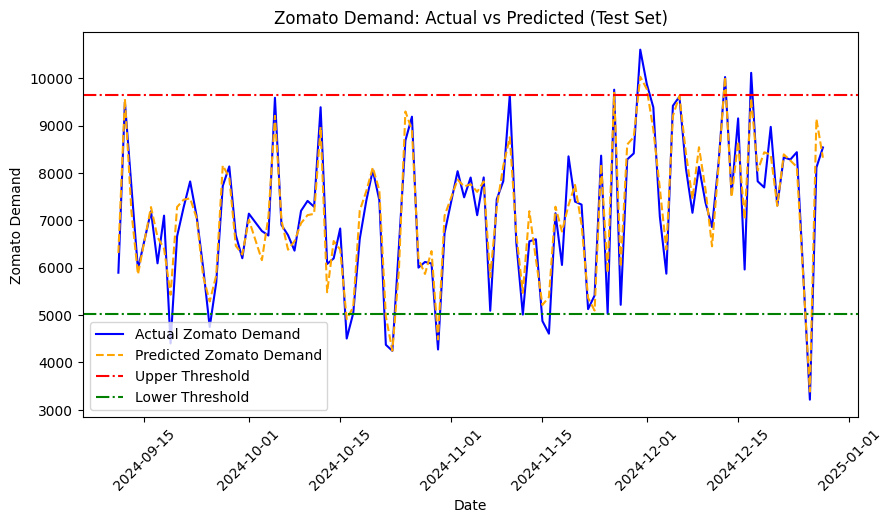

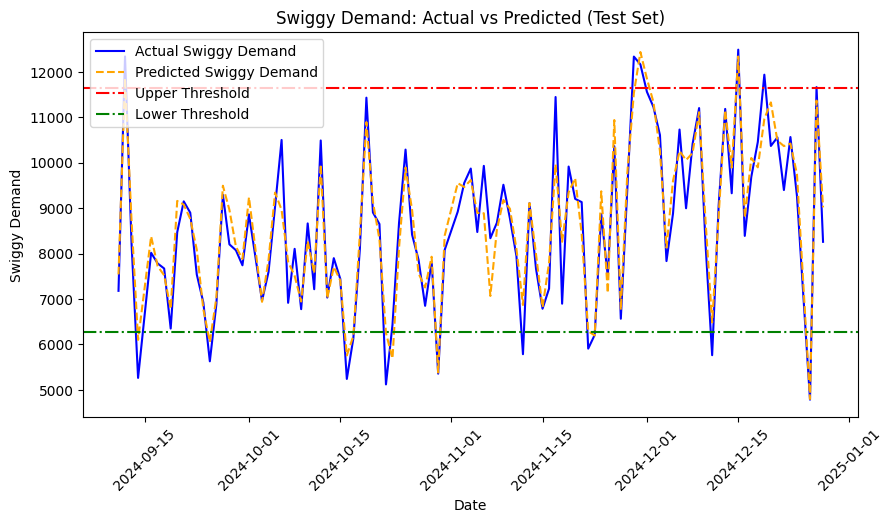

In [17]:
# Compute threshold values dynamically
zomato_upper_threshold = np.percentile(actual_demand_test[:, 0], 95)  # 95th percentile
zomato_lower_threshold = np.percentile(actual_demand_test[:, 0], 10)  # 10th percentile

swiggy_upper_threshold = np.percentile(actual_demand_test[:, 1], 95)  # 95th percentile
swiggy_lower_threshold = np.percentile(actual_demand_test[:, 1], 10)  # 10th percentile

# Plot for Zomato demand
plt.figure(figsize=(10, 5))
plt.plot(test_dates, actual_demand_test[:, 0], label='Actual Zomato Demand', color='blue')
plt.plot(test_dates, predicted_demand_test[:, 0], label='Predicted Zomato Demand', linestyle='--', color='orange')
plt.axhline(y=zomato_upper_threshold, color='r', linestyle='-.', label="Upper Threshold")  # Upper threshold
plt.axhline(y=zomato_lower_threshold, color='g', linestyle='-.', label="Lower Threshold")  # Lower threshold
plt.title('Zomato Demand: Actual vs Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Zomato Demand')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Plot for Swiggy demand
plt.figure(figsize=(10, 5))
plt.plot(test_dates, actual_demand_test[:, 1], label='Actual Swiggy Demand', color='blue')
plt.plot(test_dates, predicted_demand_test[:, 1], label='Predicted Swiggy Demand', linestyle='--', color='orange')
plt.axhline(y=swiggy_upper_threshold, color='r', linestyle='-.', label="Upper Threshold")  # Upper threshold
plt.axhline(y=swiggy_lower_threshold, color='g', linestyle='-.', label="Lower Threshold")  # Lower threshold
plt.title('Swiggy Demand: Actual vs Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Swiggy Demand')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Compute MAE
mae_zomato = mean_absolute_error(actual_demand_test[:, 0], predicted_demand_test[:, 0])
mae_swiggy = mean_absolute_error(actual_demand_test[:, 1], predicted_demand_test[:, 1])

# Compute RMSE
rmse_zomato = np.sqrt(mean_squared_error(actual_demand_test[:, 0], predicted_demand_test[:, 0]))
rmse_swiggy = np.sqrt(mean_squared_error(actual_demand_test[:, 1], predicted_demand_test[:, 1]))

# Compute R² Score
r2_zomato = r2_score(actual_demand_test[:, 0], predicted_demand_test[:, 0])
r2_swiggy = r2_score(actual_demand_test[:, 1], predicted_demand_test[:, 1])

# Print results
print(f"Test Set Evaluation:")
print(f"Zomato Demand - MAE: {mae_zomato:.4f}, RMSE: {rmse_zomato:.4f}, R²: {r2_zomato:.4f}")
print(f"Swiggy Demand - MAE: {mae_swiggy:.4f}, RMSE: {rmse_swiggy:.4f}, R²: {r2_swiggy:.4f}")


Test Set Evaluation:
Zomato Demand - MAE: 414.5111, RMSE: 536.2466, R²: 0.8838
Swiggy Demand - MAE: 468.7838, RMSE: 579.4033, R²: 0.9045


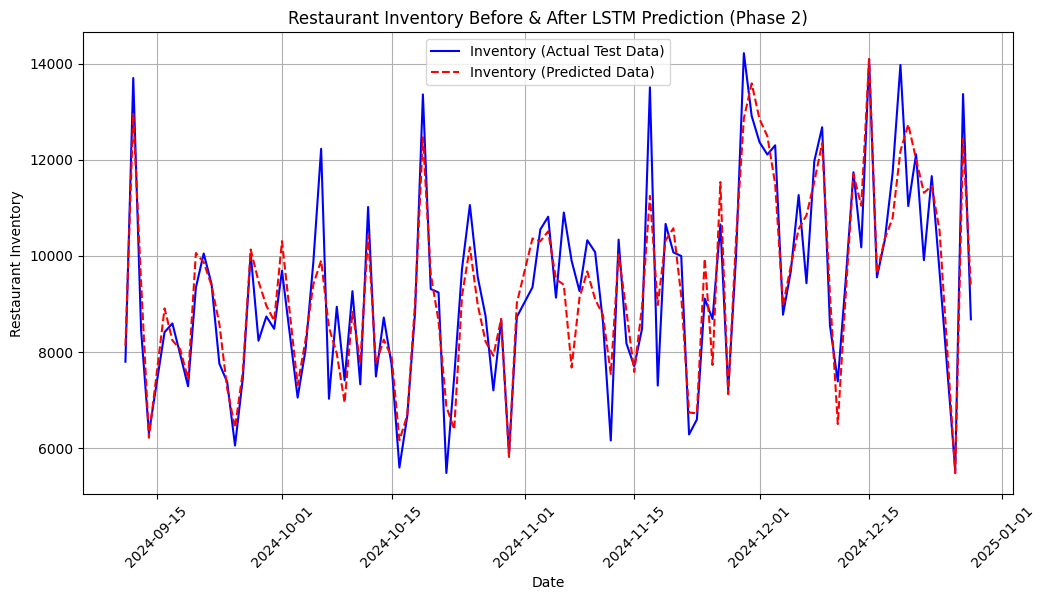

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_newsvendor_inventory(demand, std_dev, z_value=1.96):
    """
    Calculate optimal restaurant inventory based on demand and standard deviation.
    :param demand: Mean demand value
    :param std_dev: Standard deviation of demand
    :param z_value: Z-score to ensure safety stock (default ~90% service level)
    :return: Computed inventory level
    """
    return np.round(demand + z_value * std_dev)

# Compute Mean & Std Dev from Actual Test Data
test_demand_mean = np.mean(actual_demand_test, axis=1)  # Mean demand per day
test_demand_std = np.std(actual_demand_test, axis=1)    # Std dev per day

# Compute Mean & Std Dev from Predicted Data
pred_demand_mean = np.mean(predicted_demand_test, axis=1)  # Mean demand per day
pred_demand_std = np.std(predicted_demand_test, axis=1)    # Std dev per day

# Calculate Restaurant Inventory for Test & Predicted Demand
restaurant_inventory_test = calculate_newsvendor_inventory(test_demand_mean, test_demand_std)
restaurant_inventory_pred = calculate_newsvendor_inventory(pred_demand_mean, pred_demand_std)

# Plot Inventory Levels
plt.figure(figsize=(12, 6))
plt.plot(test_dates, restaurant_inventory_test, label="Inventory (Actual Test Data)", color='blue')
plt.plot(test_dates, restaurant_inventory_pred, label="Inventory (Predicted Data)", linestyle='dashed', color='red')

plt.xlabel("Date")
plt.ylabel("Restaurant Inventory")
plt.title("Restaurant Inventory Before & After LSTM Prediction (Phase 2)")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()
